## Functions and Imports

In [78]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import re
import seaborn as sns
import matplotlib.ticker as mticker

# Add sibling folder to sys.path (for notebooks)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'y_utils')))

import functions  # now import your module
import config

import sys
sys.stdout.flush()

In [79]:
def plot_cf_timeseries(model, title=None, pop_col="pop", show_plot=True):
    """
    Plots actual vs counterfactual suicide rate and model attribution over time (by year).

    Parameters:
    - model (str): Model name to fetch input files.
    - title (str, optional): Title to show on plot.
    - pop_col (str): Population column to use for weighting.
    - show_plot (bool): Whether to display the plot.

    Returns:
    - pd.DataFrame: Merged timeseries DataFrame.
    """
    print(f"Generating plot for model: {model}")

    # Load data
    df_full = pd.read_csv(config.get_combined_fullsample_attr(model))

    required_cols = {"poly_id_int", "suiciderate", "year"}

    if pop_col:
        required_cols.add(pop_col)

    missing_cols = required_cols - set(df_full.columns)
    if missing_cols:
        print(f"❌ Missing columns in dataframe: {missing_cols}")
        print(f"Available columns are: {list(df_full.columns)}")
        raise ValueError(f"Dataframe missing required columns: {missing_cols}")


    # Aggregate each variable using population-weighted mean by year
    suicide_actual = functions.filter_and_avg(df_full, county_id_col="poly_id_int", value_col="suiciderate", time_col="year", pop_col=pop_col)
    suicide_cf = functions.filter_and_avg(df_full, county_id_col="poly_id_int", value_col="cfsuiciderate_attr", time_col="year", pop_col=pop_col)
    yhat_diff = functions.filter_and_avg(df_full, county_id_col="poly_id_int", value_col="y_hat_diff", time_col="year", pop_col=pop_col)

    # Convert year to numeric in aggregated dfs 
    for df in (suicide_actual, suicide_cf, yhat_diff):
        df["year"] = pd.to_numeric(df["year"], errors='coerce')

    # Merge dataframes on year
    merged = suicide_actual.merge(suicide_cf, on="year", how="inner")
    merged = merged.merge(yhat_diff, on="year", how="inner")

    if merged.empty:
        print("❌ Merged dataset is empty. Skipping plot.")
        return merged

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(merged["year"], merged["suiciderate"], label="Observed suicide rate", color="black", lw=1.8)
    ax1.plot(merged["year"], merged["cfsuiciderate_attr"], label="Counterfactual suicide rate", color="steelblue", lw=1.8)
    ax1.set_ylabel("Suicide rate (per 100k)")
    ax1.set_xlabel("Year")

    # Set ticks every 2 years
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(2))

    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(merged["year"], merged["y_hat_diff"], label="Model attribution", color="darkred", lw=1.5, ls="--")
    ax2.set_ylabel("Model attribution (y_hat_diff)")
    ax2.legend(loc="upper right")

    if title:
        plt.title(title)

    plt.tight_layout()
    if show_plot:
        plt.show()

    return merged


In [80]:
def plot_histogram_seaborn(
    file_path,
    county_id_col,
    value_col,
    time_col=None,
    start_time=None,
    end_time=None,
    agg_method="mean",
    ax=None,
    show_plot=True
):
    df = pd.read_csv(file_path)

    if time_col and start_time is not None and end_time is not None:
        df = df[(df[time_col] >= start_time) & (df[time_col] <= end_time)]

    if df.empty or value_col not in df.columns:
        print(f"No data found or column '{value_col}' missing.")
        return None

    # Aggregate
    if time_col:
        df_agg = df.groupby([county_id_col])[value_col].agg(agg_method).reset_index()
    else:
        df_agg = df[[county_id_col, value_col]].copy()
        df_agg = df_agg.groupby(county_id_col)[value_col].agg(agg_method).reset_index()

    # Clean
    series = df_agg[value_col].replace([float("inf"), -float("inf")], pd.NA).dropna()

    if series.empty:
        print(f"No valid data to plot for '{value_col}'")
        return None

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    sns.histplot(series, bins=30, kde=False, ax=ax)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f"{agg_method.title()} of {value_col} ({len(series)} counties)")
    ax.set_xlabel(value_col)

    if show_plot:
        plt.tight_layout()
        plt.show()

    return df_agg


In [81]:
def plot_histogram_with_zero_split(
    file_path,
    county_id_col,
    value_col,
    time_col=None,
    start_time=None,
    end_time=None,
    agg_method='mean',
    bins=30,
    ax=None,           # NEW: axis to plot on
    show_plot=True,     # optional, only used if ax is None
    title = "histogram"
):
    df = pd.read_csv(file_path)

    agg_df = functions.filter_and_avg(df, county_id_col, value_col, time_col, start_time, end_time, agg_method)
    if agg_df is None or agg_df.empty:
        print(f"❌ No data available after filtering and aggregation for {value_col}.")
        return None

    values_with_na = agg_df[value_col]
    num_nas = values_with_na.isna().sum()
    if num_nas > 0:
        print(f"⚠️ Warning: {num_nas} NA values found and dropped for {value_col}.")
    values = values_with_na.dropna().values
    if len(values) == 0:
        print(f"❌ All aggregated values are NA for {value_col}.")
        return None

    vmin = np.min(values)
    vmax = np.max(values)

    if vmin > 0:
        vmin = 0
    if vmax < 0:
        vmax = 0

    total_bins = bins
    neg_range = abs(vmin) if vmin < 0 else 0
    pos_range = vmax if vmax > 0 else 0
    total_range = neg_range + pos_range

    if total_range == 0:
        bin_edges = np.array([-0.1, 0, 0.1])
    else:
        neg_bins = int(round(total_bins * (neg_range / total_range))) if neg_range > 0 else 0
        pos_bins = total_bins - neg_bins

        if neg_bins == 0 and neg_range > 0:
            neg_bins = 1
            pos_bins = max(total_bins - 1, 0)
        if pos_bins == 0 and pos_range > 0:
            pos_bins = 1
            neg_bins = max(total_bins - 1, 0)

        neg_edges = np.linspace(vmin, 0, neg_bins + 1) if neg_bins > 0 else np.array([0])
        pos_edges = np.linspace(0, vmax, pos_bins + 1) if pos_bins > 0 else np.array([0])

        if neg_bins > 0 and pos_bins > 0:
            bin_edges = np.concatenate([neg_edges[:-1], pos_edges])
        else:
            bin_edges = neg_edges if neg_bins > 0 else pos_edges

    counts, edges = np.histogram(values, bins=bin_edges)

    colors = []
    for left_edge, right_edge in zip(edges[:-1], edges[1:]):
        if right_edge <= 0:
            colors.append('blue')
        elif left_edge >= 0:
            colors.append('red')
        else:
            colors.append('gray')

    centers = (edges[:-1] + edges[1:]) / 2
    widths = np.diff(edges) * 0.9

    # Plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(centers, counts, width=widths, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_xlabel(value_col)
    ax.set_ylabel("Number of Counties")
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.6)

    if show_plot and ax is None:
        plt.tight_layout()
        plt.show()

    if ax is None:
        return fig, ax
    else:
        return ax


In [82]:
def plot_dose_response_from_betas(regression_beta_fp, title="Dose-Response Function: Temperature on Suicide", poly_max=4):
    """
    Reads distributed lag regression betas, extracts polynomial terms,
    computes total effect, and plots a dose-response curve with gradient color.

    Parameters:
    -----------
    regression_beta_fp : str
        File path to CSV with regression output. Must contain columns 'term' and 'beta'.
    title : str
        Title for the plot.
    poly_max : int
        Maximum polynomial degree to include (default is 4).
    """
    # Load betas
    regression_betas = pd.read_csv(regression_beta_fp)

    # Extract polynomial degree and lag from term names like "tavg_poly3_l2"
    def extract_poly_and_lag(term):
        m = re.match(r"tavg_poly(\d)_l(\d+)", term)
        return (int(m.group(1)), int(m.group(2))) if m else (None, None)

    regression_betas['poly'], regression_betas['lag'] = zip(*regression_betas['term'].map(extract_poly_and_lag))
    regression_betas = regression_betas.dropna(subset=['poly', 'lag'])

    # Sum betas across lags for each polynomial degree
    sum_betas = regression_betas.groupby('poly')['beta'].sum().sort_index()
    betas = [sum_betas.get(i, 0) for i in range(1, poly_max + 1)]

    # Define dose-response curve
    def dose_response_curve(x, coefs):
        return sum(coef * (x ** i) for i, coef in enumerate(coefs, start=1))

    # Generate curve
    x_vals = np.linspace(-5, 30, 500)
    y_vals = dose_response_curve(x_vals, betas)

    # Create a gradient line
    points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(x_vals.min(), x_vals.max())
    lc = LineCollection(segments, cmap='coolwarm', norm=norm)
    lc.set_array(x_vals)
    lc.set_linewidth(2)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.add_collection(lc)
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(y_vals.min() - 0.1 * abs(y_vals.min()), y_vals.max() + 0.1 * abs(y_vals.max()))
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    # Labels
    fig.suptitle(title, fontsize=14)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Estimated Effect on Suicide Rate")

    # Colorbar
    cbar = fig.colorbar(lc, ax=ax)
    cbar.set_label("Temperature (°C)")

    # Caption
    plt.figtext(0.5, 0.01,
                "Effect computed as sum of lagged polynomial betas from distributed lag regression.",
                ha='center', va='bottom', fontsize=9)

    plt.grid(True)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


In [83]:
def plot_time_series_attr(
    dataset_fp,
    column_to_plot,
    second_column_to_plot=None,      # NEW: optional second variable
    time_agg_method="average",       # "sum", "average", or None/"none"
    year_range=None,                 # (start_year, end_year), inclusive
    y_range=None,                    # (ymin, ymax), or None for auto
    county_code=None,                # FIPS code or None to aggregate
    county_agg_method="average",     # "sum" or "average"
    plot_all_counties=False,         # light grey lines for all counties
    title="Time Series Plot",
    ax = None
):
    # ---------- Load and prepare data ----------
    df = pd.read_csv(dataset_fp)

    # --- Check that required columns exist ---
    required_cols = ["year", "month", column_to_plot]
    if second_column_to_plot:
        required_cols.append(second_column_to_plot)

    for col in required_cols:
        if col not in df.columns:
            print(f"❌ Column '{col}' not found in dataset!")
            print("Available columns:")
            print(df.columns.tolist())
            raise ValueError(f"Missing required column: {col}")

    df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))

    if year_range:
        start_year, end_year = year_range
        df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]

    # ---------- County filtering or aggregation ----------
    if county_code is not None:
        df = df[df["fips"] == county_code]
        line_label = f"County {county_code}"
    else:
        group_func = "mean" if county_agg_method == "average" else "sum"
        df = df.groupby("date")[column_to_plot].agg(group_func).reset_index()
        line_label = f"All Counties ({county_agg_method})"

    # ---------- Time aggregation ----------
    if time_agg_method in ["average", "sum"]:
        agg_func = "mean" if time_agg_method == "average" else "sum"
        df["year"] = df["date"].dt.year
        df = df.groupby("year")[column_to_plot].agg(agg_func).reset_index()
        df["date"] = pd.to_datetime(df["year"].astype(str) + "-01-01")
    elif time_agg_method in [None, "none"]:
        pass
    else:
        raise ValueError("time_agg_method must be 'average', 'sum', or None/'none'.")

    # ---------- Optional second variable ----------
    if second_column_to_plot:
        df2 = pd.read_csv(dataset_fp)
        df2["date"] = pd.to_datetime(df2[["year", "month"]].assign(day=1))

        if year_range:
            df2 = df2[(df2["year"] >= start_year) & (df2["year"] <= end_year)]

        if county_code is not None:
            df2 = df2[df2["fips"] == county_code]
        else:
            group_func = "mean" if county_agg_method == "average" else "sum"
            df2 = df2.groupby("date")[second_column_to_plot].agg(group_func).reset_index()

        if time_agg_method in ["average", "sum"]:
            agg_func = "mean" if time_agg_method == "average" else "sum"
            df2["year"] = df2["date"].dt.year
            df2 = df2.groupby("year")[second_column_to_plot].agg(agg_func).reset_index()
            df2["date"] = pd.to_datetime(df2["year"].astype(str) + "-01-01")
        elif time_agg_method in [None, "none"]:
            pass
        else:
            raise ValueError("Invalid time_agg_method for second column")

    # ---------- Plotting ----------
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
        show_plot = True
    else:
        show_plot = False

    if plot_all_counties:
        all_df = pd.read_csv(dataset_fp)
        all_df["date"] = pd.to_datetime(all_df[["year", "month"]].assign(day=1))
        all_df = all_df[(all_df["year"] >= df["date"].dt.year.min()) & (all_df["year"] <= df["date"].dt.year.max())]

        for fips_code, subdf in all_df.groupby("poly_id_int"):
            subdf = subdf.copy()
            if time_agg_method in ["average", "sum"]:
                subdf["year"] = subdf["date"].dt.year
                group_func = "mean" if time_agg_method == "average" else "sum"
                subdf = subdf.groupby("year")[column_to_plot].agg(group_func).reset_index()
                subdf["date"] = pd.to_datetime(subdf["year"].astype(str) + "-01-01")
            ax.plot(subdf["date"], subdf[column_to_plot], color="lightgrey", linewidth=0.8, alpha=0.6)

    ax.plot(df["date"], df[column_to_plot], color="red", linewidth=2.5, label=column_to_plot)

    if second_column_to_plot:
        ax.plot(df2["date"], df2[second_column_to_plot], color="blue", linewidth=2, linestyle="--", label=second_column_to_plot)

    if y_range:
        ax.set_ylim(*y_range)

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(True)
    ax.legend()

    if show_plot:
        plt.tight_layout()
        plt.show()


In [84]:
def plot_time_series_all_models(
    models,
    value_col: str,
    time_agg_method: str = "average",  # or "sum"
    county_agg_method: str = "average",  # or "sum"
    county_id: int = None,
    start_date: str = None,  # expects "YYYYMM" string or None
    end_date: str = None,    # expects "YYYYMM" string or None
    y_range: tuple = None,
    title: str = "",
    ax=None,
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Convert strings like "YYYYMM" to pd.Timestamp, or None
    start_ts = pd.to_datetime(start_date, format="%Y%m") if start_date else None
    end_ts = pd.to_datetime(end_date, format="%Y%m") if end_date else None

    for model in models:
        file_path = config.get_combined_fullsample_attr(model)
        if not os.path.exists(file_path):
            print(f"[WARNING] File for model {model} not found: {file_path}")
            continue

        df = pd.read_csv(file_path)

        if value_col not in df.columns:
            print(f"[ERROR] Column '{value_col}' not found in {file_path}")
            print("Available columns:", df.columns.tolist())
            return

        df["yearmonth"] = pd.to_datetime(df["year"].astype(str) + df["month"].astype(str).str.zfill(2), format="%Y%m")

        if start_ts:
            df = df[df["yearmonth"] >= start_ts]
        if end_ts:
            df = df[df["yearmonth"] <= end_ts]

        if county_id is not None:
            df = df[df["poly_id_int"] == county_id]
        else:
            if county_agg_method == "sum":
                df = df.groupby("yearmonth")[value_col].sum().reset_index()
            else:
                df = df.groupby("yearmonth")[value_col].mean().reset_index()

        if time_agg_method in ["sum", "average"]:
            df["year"] = df["yearmonth"].dt.year
            if time_agg_method == "sum":
                df = df.groupby("year")[value_col].sum().reset_index()
            else:
                df = df.groupby("year")[value_col].mean().reset_index()
            group_col = "year"
        else:
            group_col = "yearmonth"

        ax.plot(df[group_col], df[value_col], label=model)

    ax.set_title(title or f"{value_col} over time by model")
    ax.set_xlabel("Time")
    ax.set_ylabel(value_col)
    if y_range:
        ax.set_ylim(y_range)
    ax.grid(True)
    ax.legend()
    
    if ax is None:
        plt.tight_layout()
        plt.show()


In [85]:
models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]

## Plotting

### Response curves

In [ ]:
plot_dose_response_from_betas(config.REGRESSION_BETA_FP)

### Histograms

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


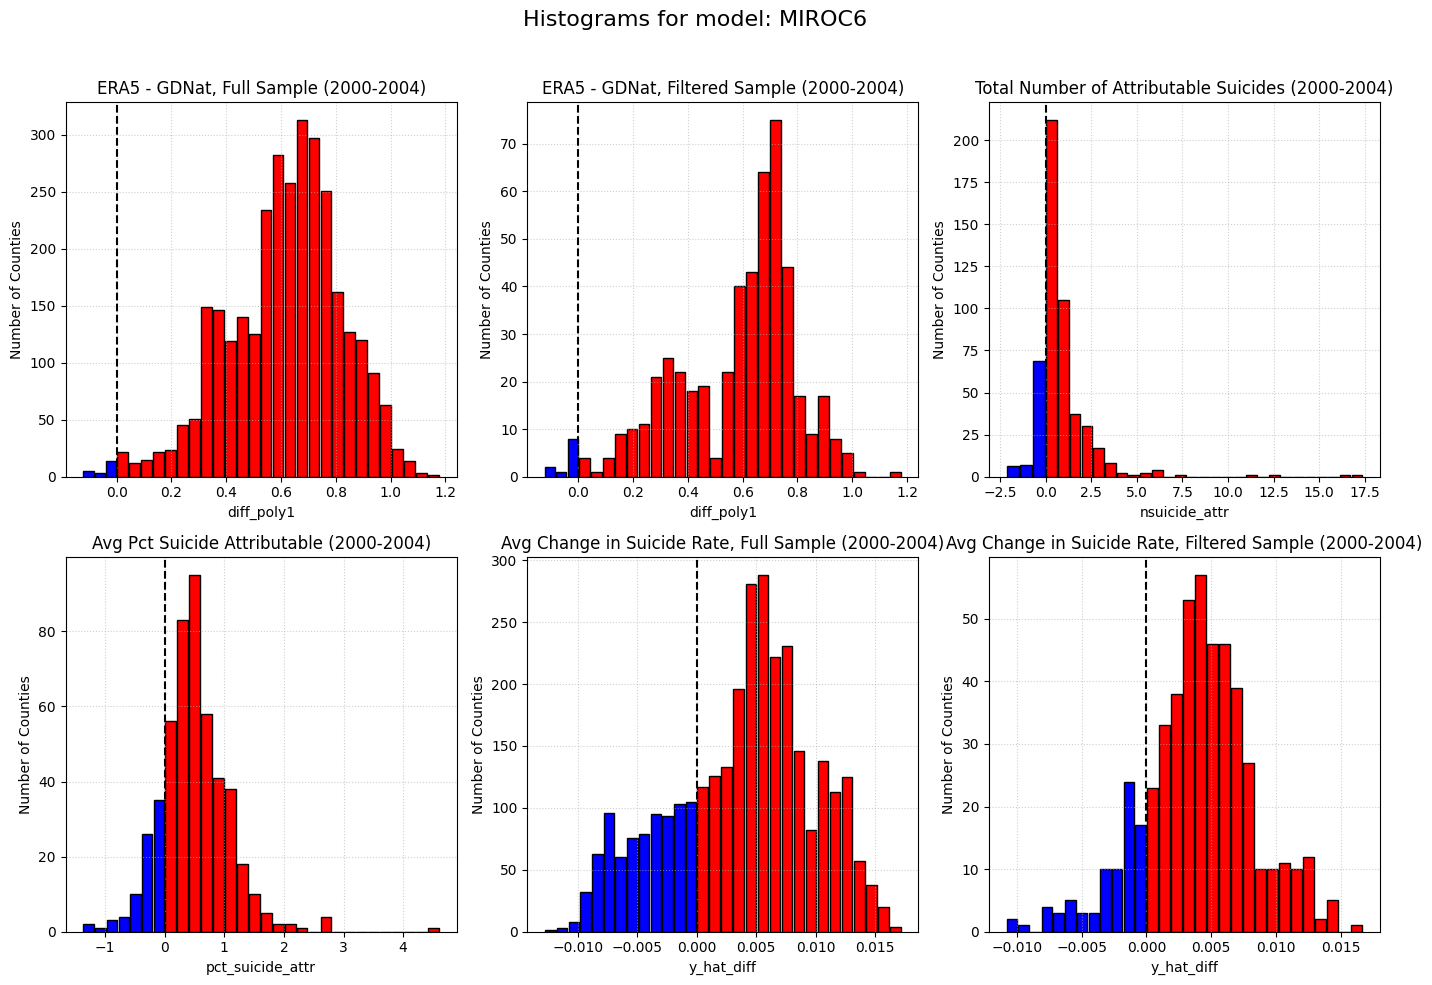

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


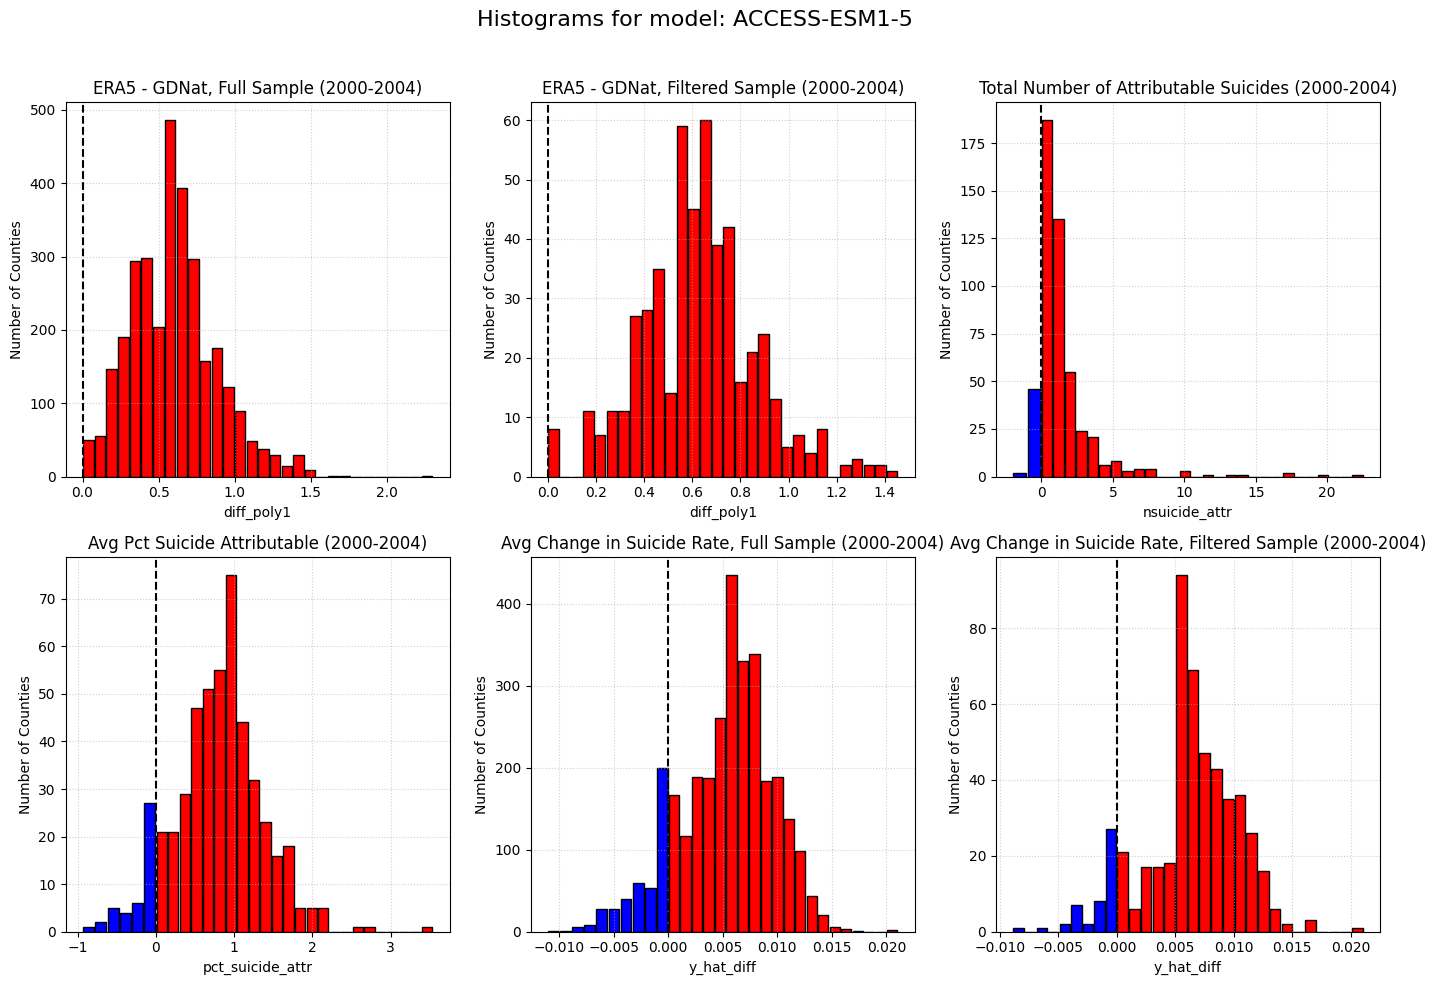

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


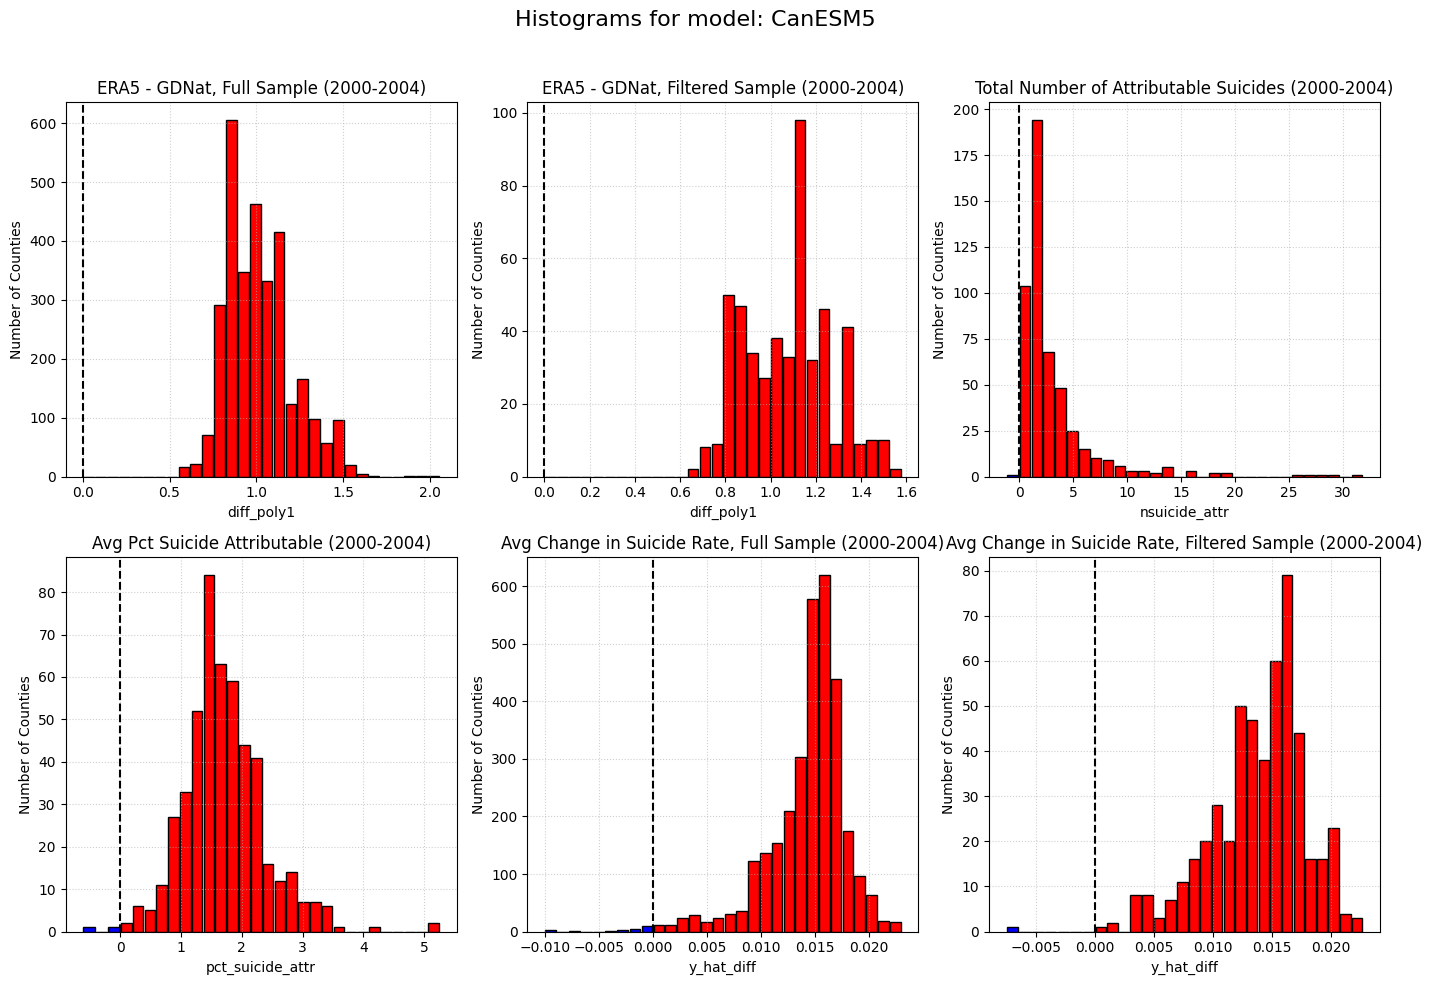

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


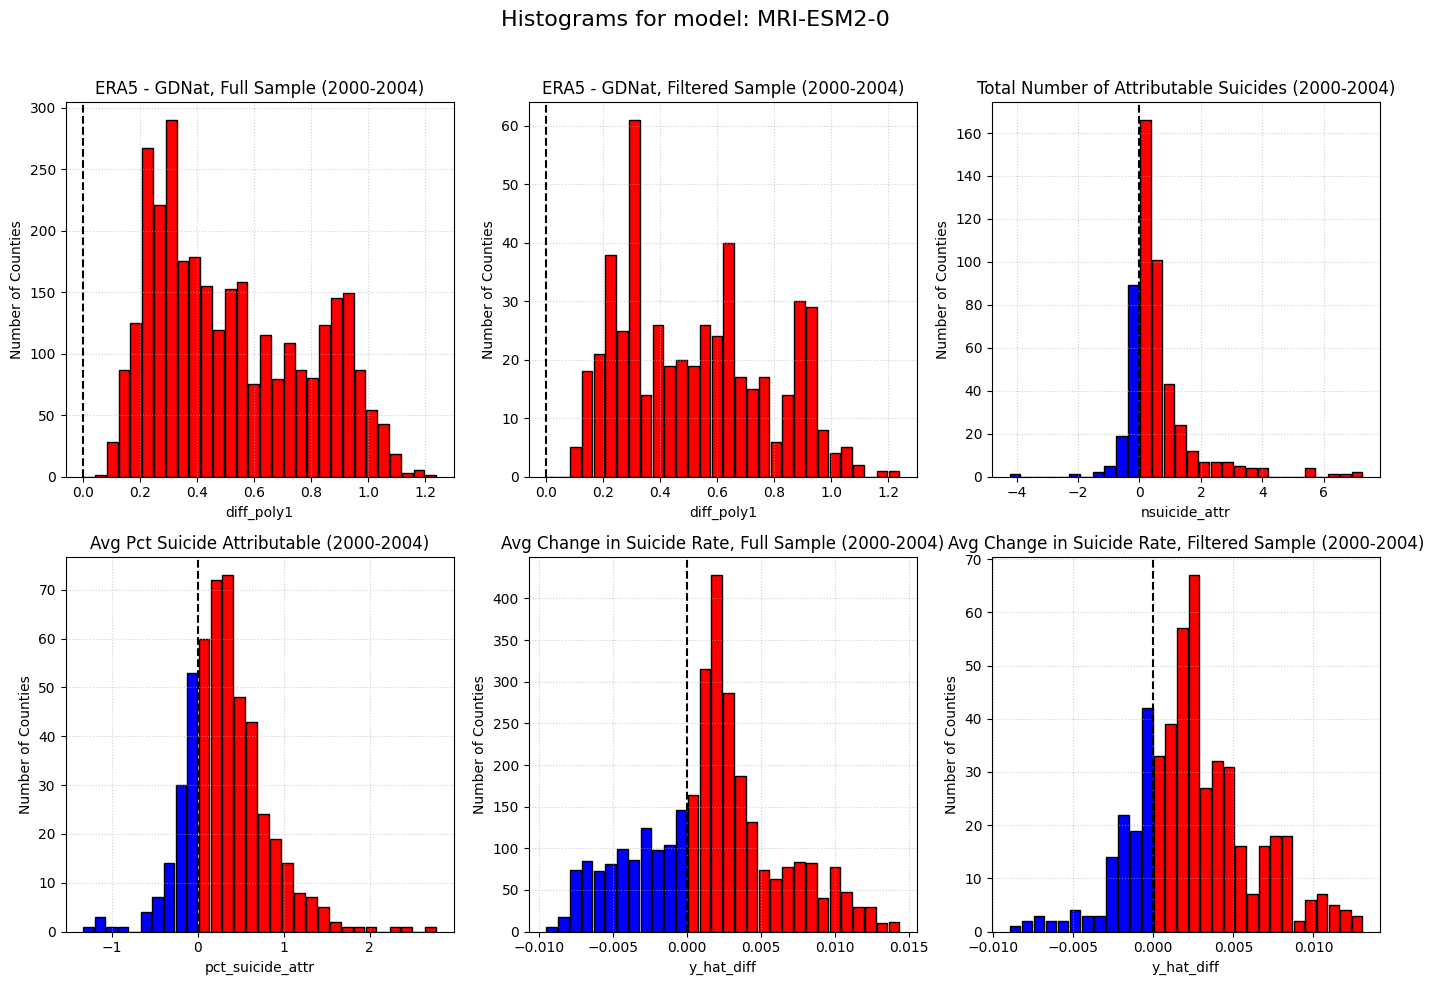

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


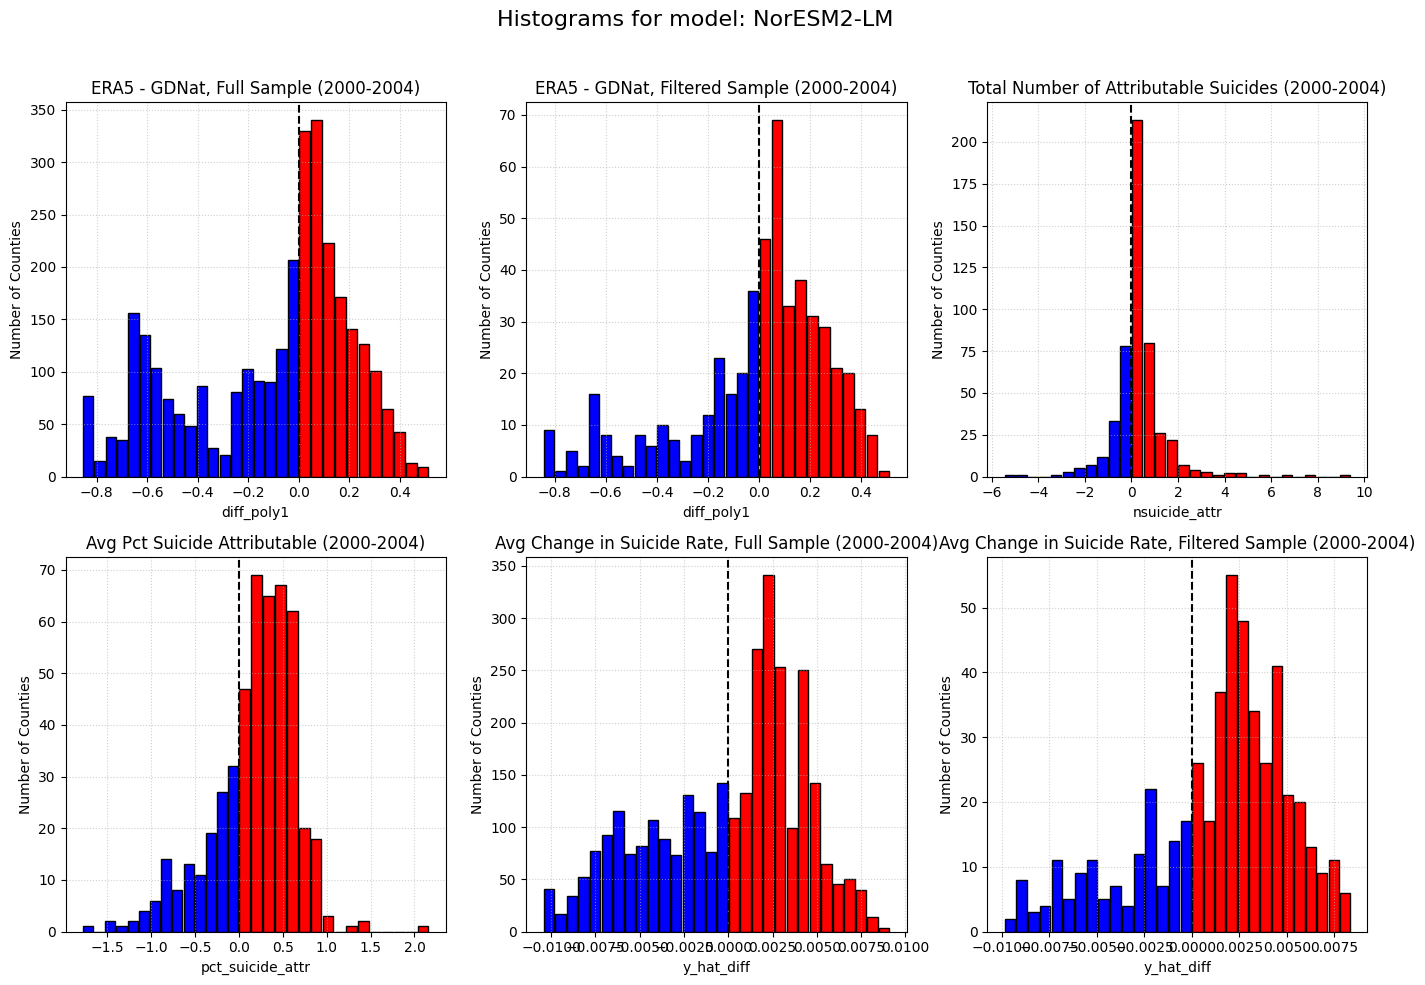

Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using SUM...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
⚠️ Warning: 10 NA values found and dropped for pct_suicide_attr.
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...


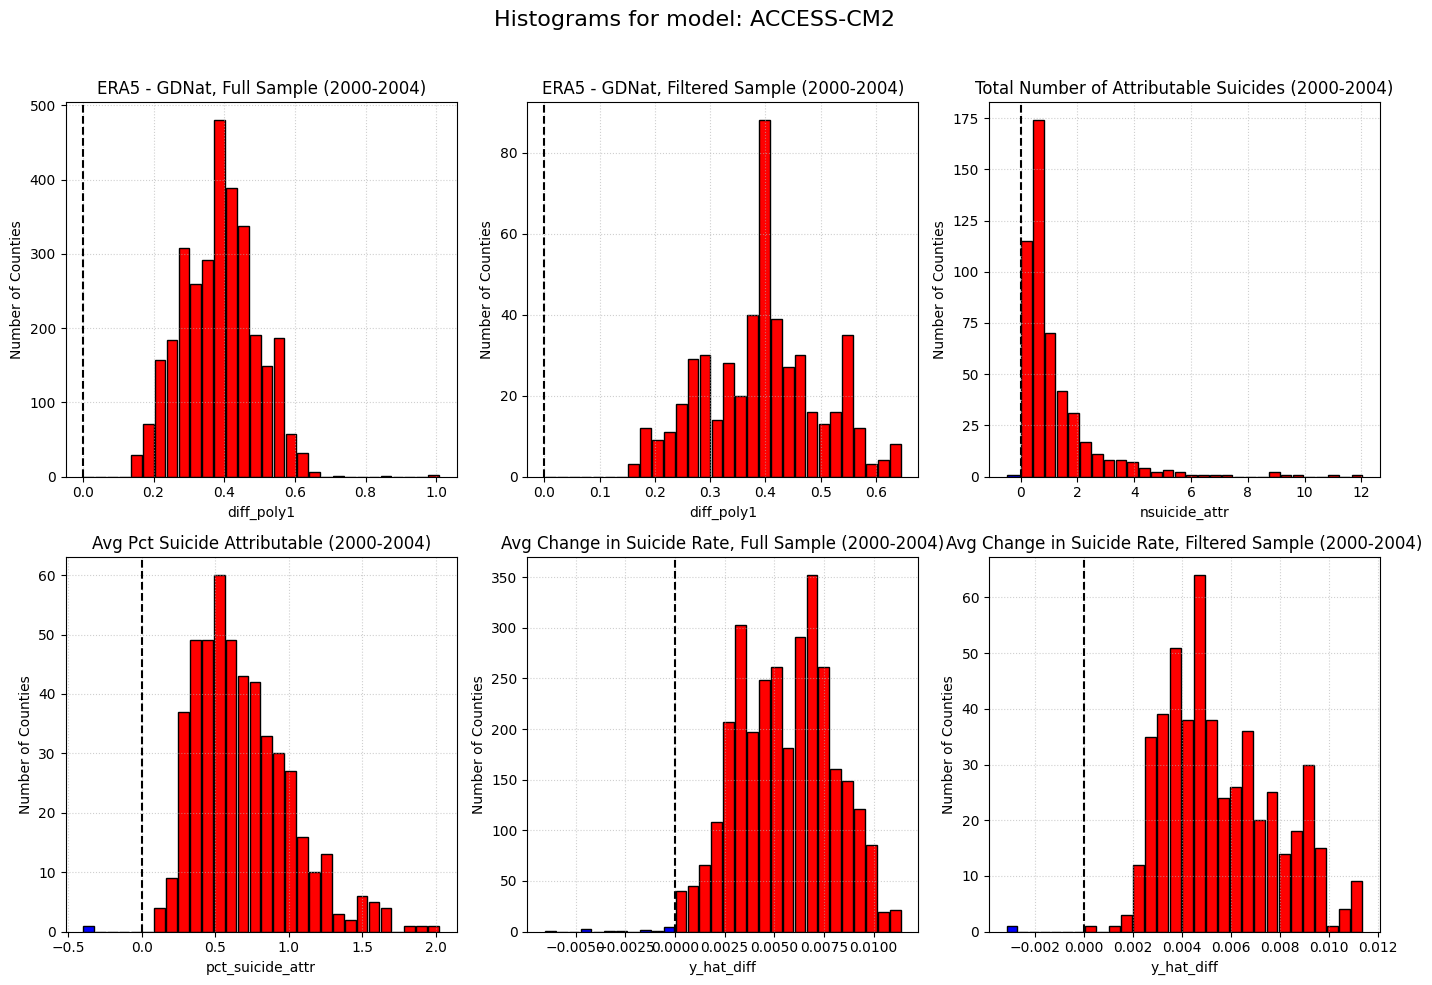

In [22]:
# The columns to plot and which function to use to get their file path
cols_and_data_func = [
    ("diff_poly1", "mean", "get_attribution_output_fp", "ERA5 - GDNat, Full Sample (2000-2004)"),
    ("diff_poly1", "mean", "get_combined_fullsample_attr", "ERA5 - GDNat, Filtered Sample (2000-2004)"),
    ("nsuicide_attr", "sum", "get_combined_fullsample_attr", "Total Number of Attributable Suicides (2000-2004)"),
    ("pct_suicide_attr", "mean", "get_combined_fullsample_attr", "Avg Pct Suicide Attributable (2000-2004)"),
    ("y_hat_diff", "mean", "get_attribution_output_fp", "Avg Change in Suicide Rate, Full Sample (2000-2004)"),
    ("y_hat_diff", "mean", "get_combined_fullsample_attr", "Avg Change in Suicide Rate, Filtered Sample (2000-2004)"),
]

def plot_for_model(model):
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (col, agg, data_func_name, plot_title) in zip(axes, cols_and_data_func):
        # Get file path by calling the right config function dynamically
        if data_func_name == "get_attribution_output_fp":
            file_path = config.get_attribution_output_fp(model)
        elif data_func_name == "get_combined_fullsample_attr":
            file_path = config.get_combined_fullsample_attr(model)
        else:
            print(f"Unknown data func: {data_func_name}")
            ax.text(0.5, 0.5, "Invalid config function", ha='center', va='center')
            ax.axis('off')
            continue

        res = plot_histogram_with_zero_split(
            file_path=file_path,
            county_id_col="poly_id_int",
            value_col=col,
            time_col="year",
            start_time=2000,
            end_time=2004,
            agg_method=agg,
            bins=30,
            ax=ax,
            show_plot=False, 
            title = plot_title
        )

        if res is None:
            ax.text(0.5, 0.5, f"No data for {col}", ha='center', va='center')
            ax.axis('off')

    fig.suptitle(f"Histograms for model: {model}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Loop over your models list
for model in models:
    plot_for_model(model)


In [20]:
# histogram cross validate 

cols_and_data_func = [
    ("diff_poly1", "mean", "get_attribution_output_fp", "ERA5 - GDNat, Full Sample (2000-2004)"),
    ("diff_poly1", "mean", "get_combined_fullsample_attr", "ERA5 - GDNat, Filtered Sample (2000-2004)"),
    ("nsuicide_attr", "sum", "get_combined_fullsample_attr", "Total Number of Attributable Suicides (2000-2004)"),
    ("pct_suicide_attr", "mean", "get_combined_fullsample_attr", "Avg Pct Suicide Attributable (2000-2004)"),
    ("y_hat_diff", "mean", "get_attribution_output_fp", "Avg Change in Suicide Rate, Full Sample (2000-2004)"),
    ("y_hat_diff", "mean", "get_combined_fullsample_attr", "Avg Change in Suicide Rate, Filtered Sample (2000-2004)"),
]

def plot_for_model_seaborn(model):
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (col, agg, data_func_name, title) in zip(axes, cols_and_data_func):
        if data_func_name == "get_attribution_output_fp":
            file_path = config.get_attribution_output_fp(model)
        elif data_func_name == "get_combined_fullsample_attr":
            file_path = config.get_combined_fullsample_attr(model)
        else:
            print(f"Unknown data func: {data_func_name}")
            ax.text(0.5, 0.5, "Invalid config function", ha='center', va='center')
            ax.axis('off')
            continue

        res = plot_histogram_seaborn(
            file_path=file_path,
            county_id_col="poly_id_int",
            value_col=col,
            time_col="year",
            start_time=2000,
            end_time=2004,
            agg_method=agg,
            ax=ax,
            show_plot=False
        )

        if res is None:
            ax.text(0.5, 0.5, f"No data for {col}", ha='center', va='center')
            ax.axis('off')
        else:
            ax.set_title(title)

    fig.suptitle(f"Histograms (Seaborn) for model: {model}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()




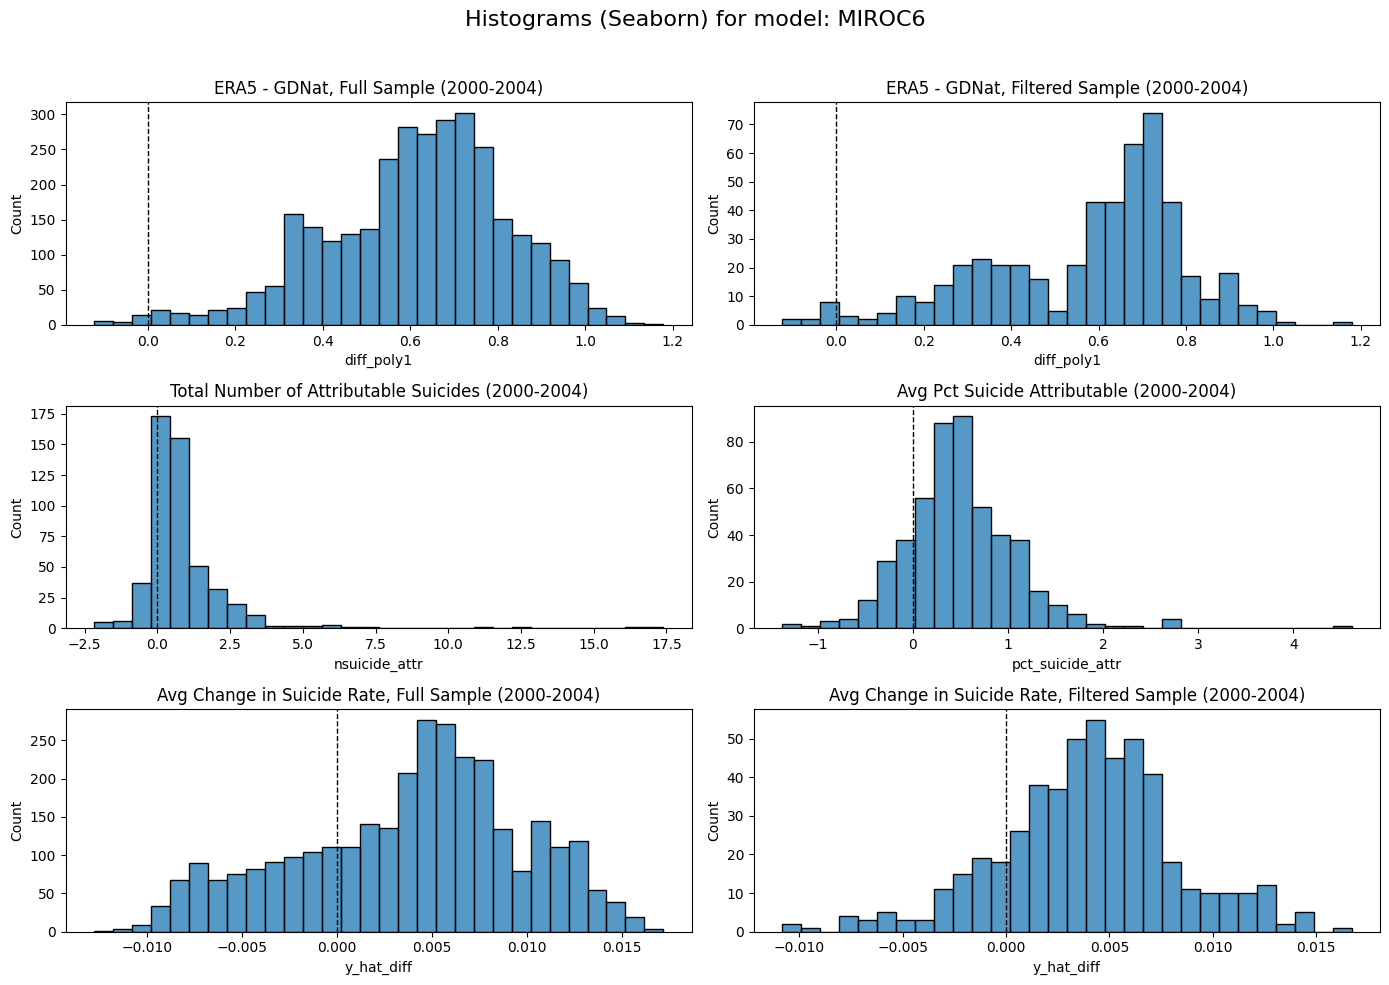

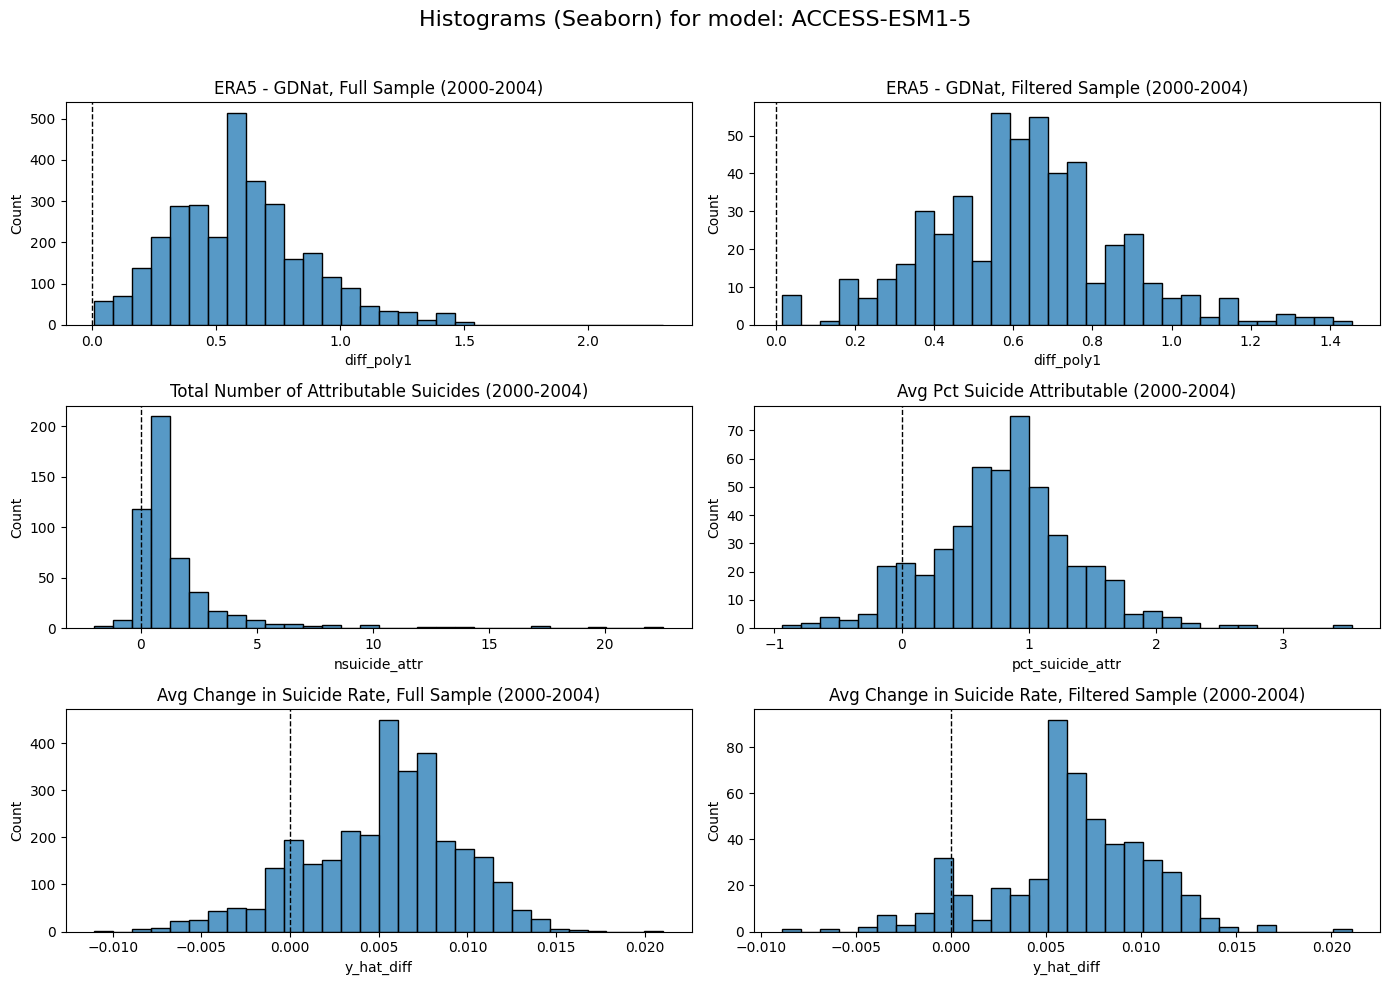

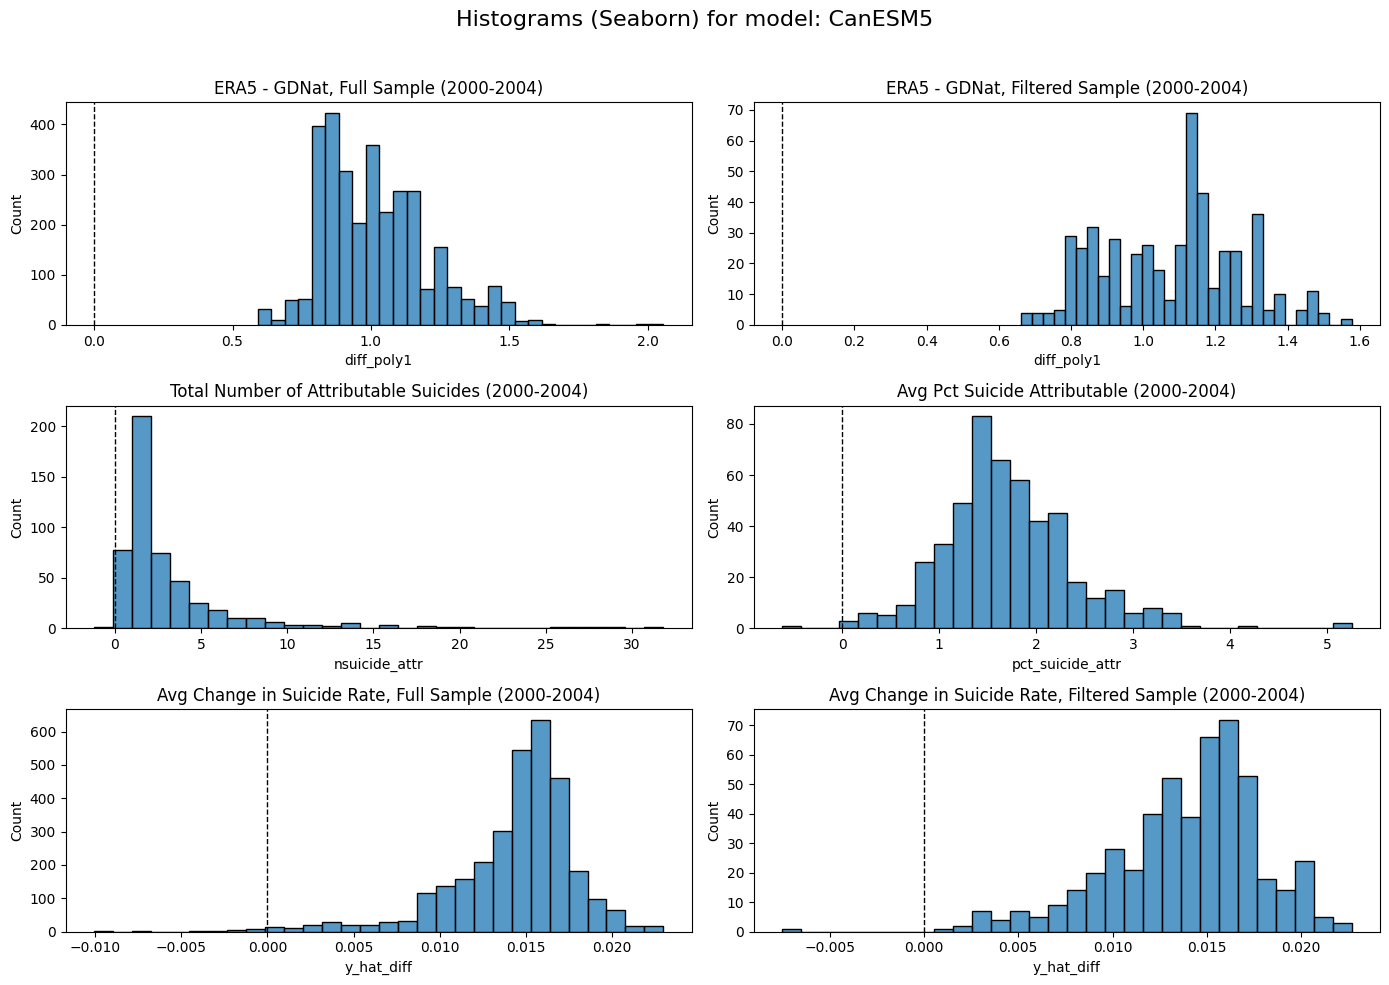

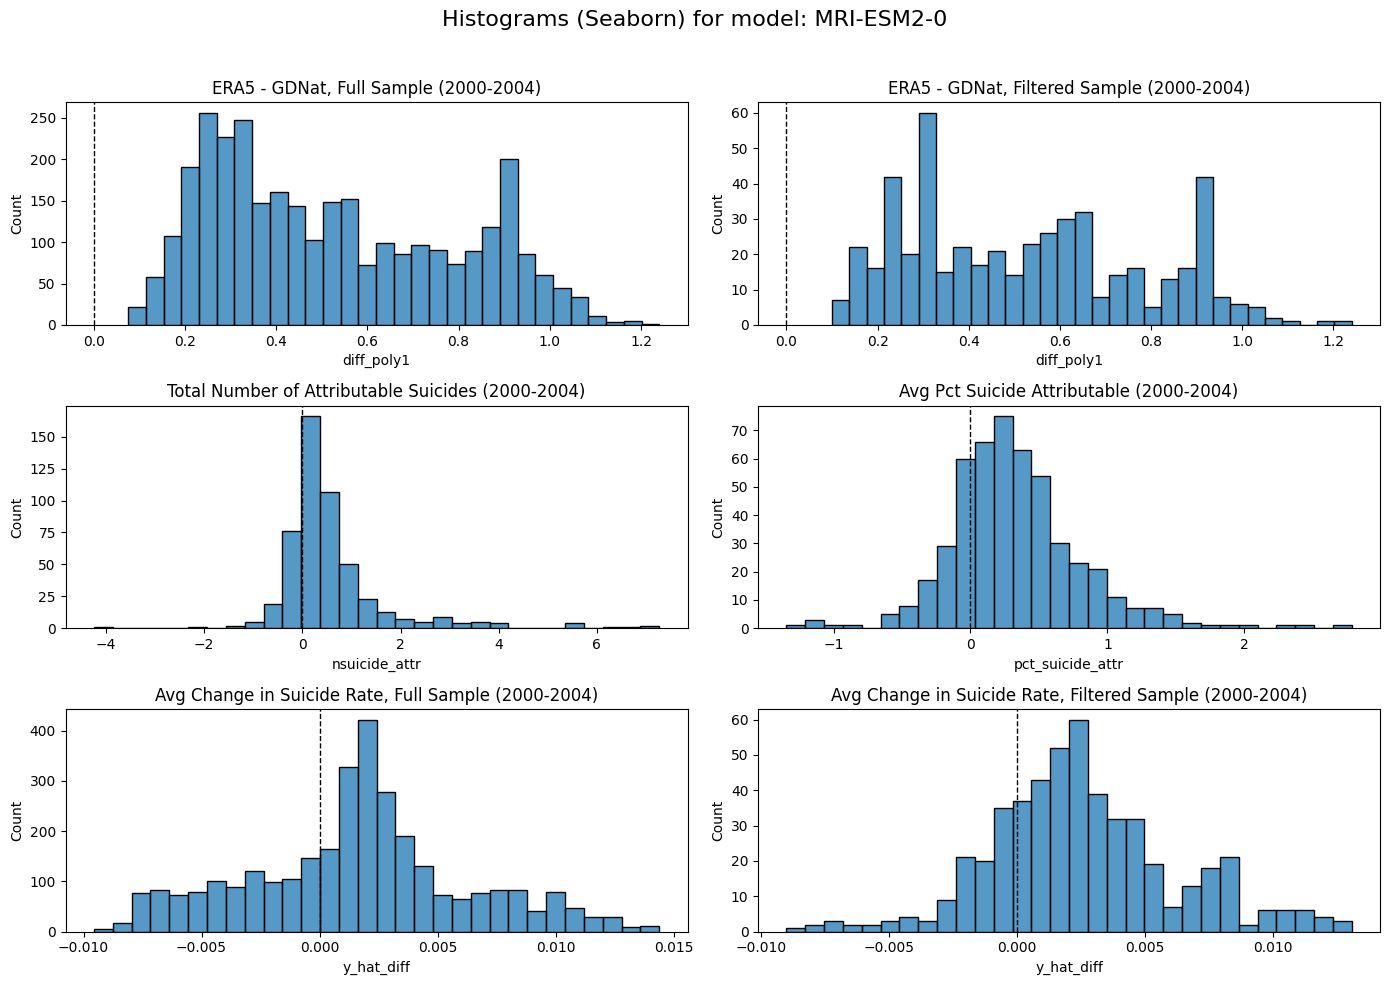

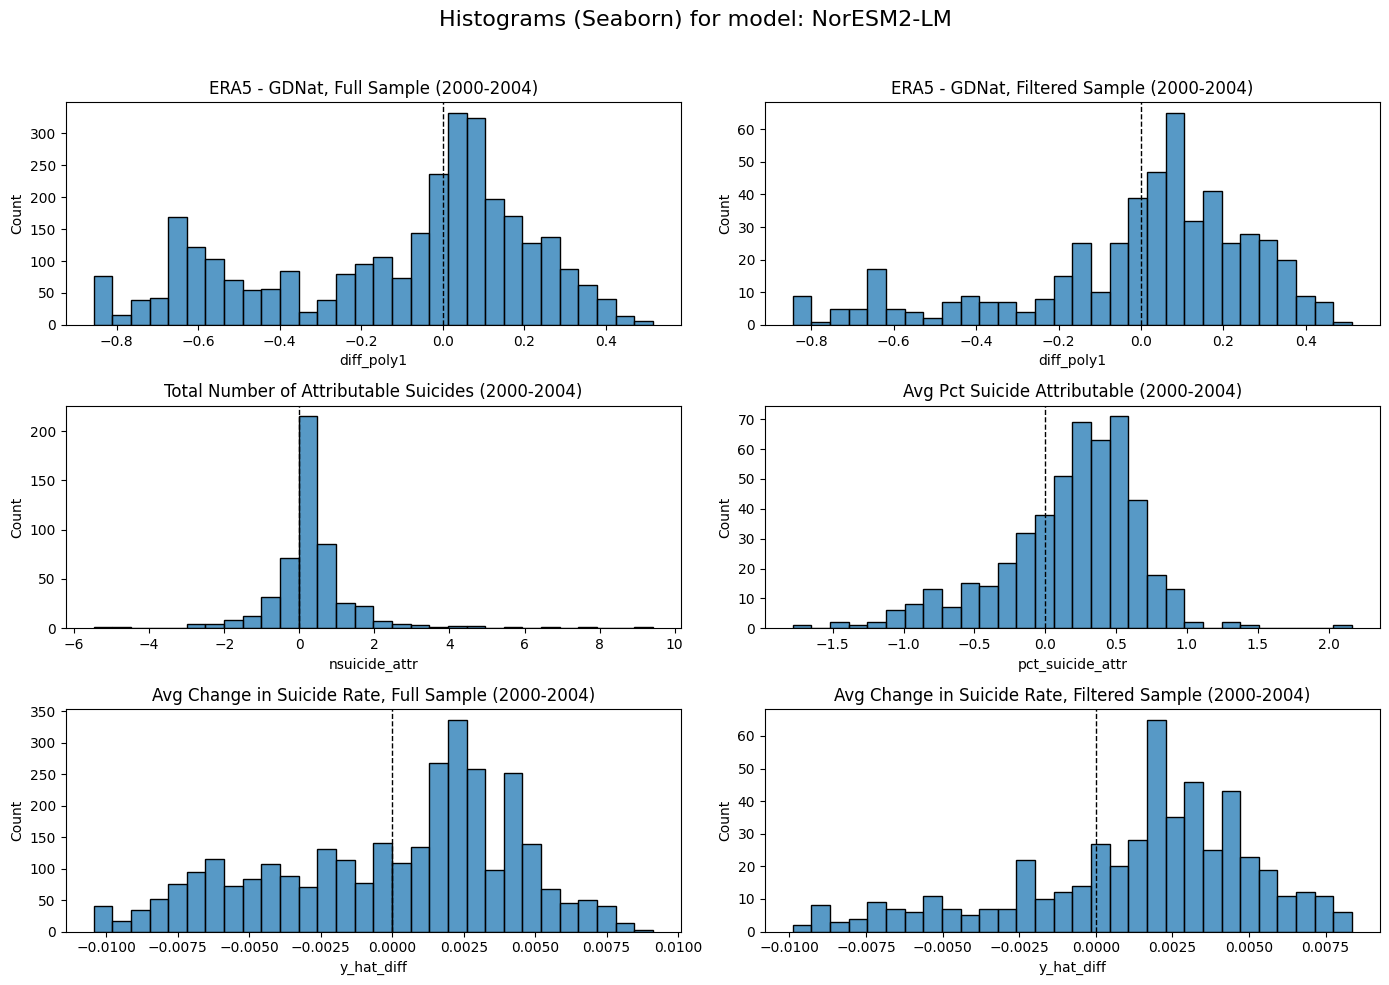

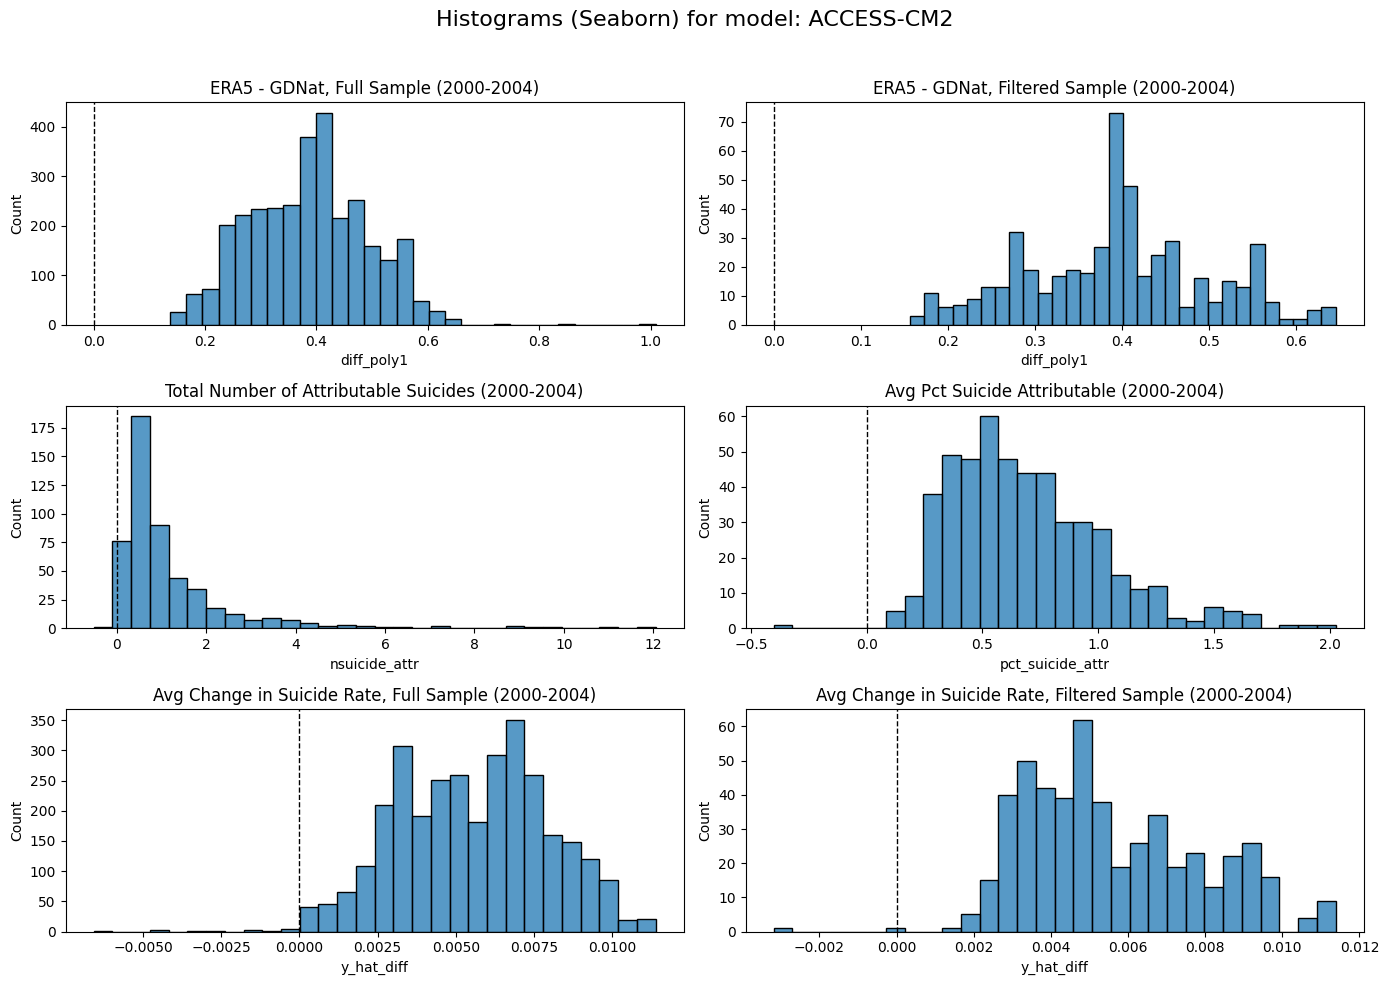

In [21]:
for model in models:
    plot_for_model_seaborn(model)


### US Time series

Generating plot for model: MIROC6
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


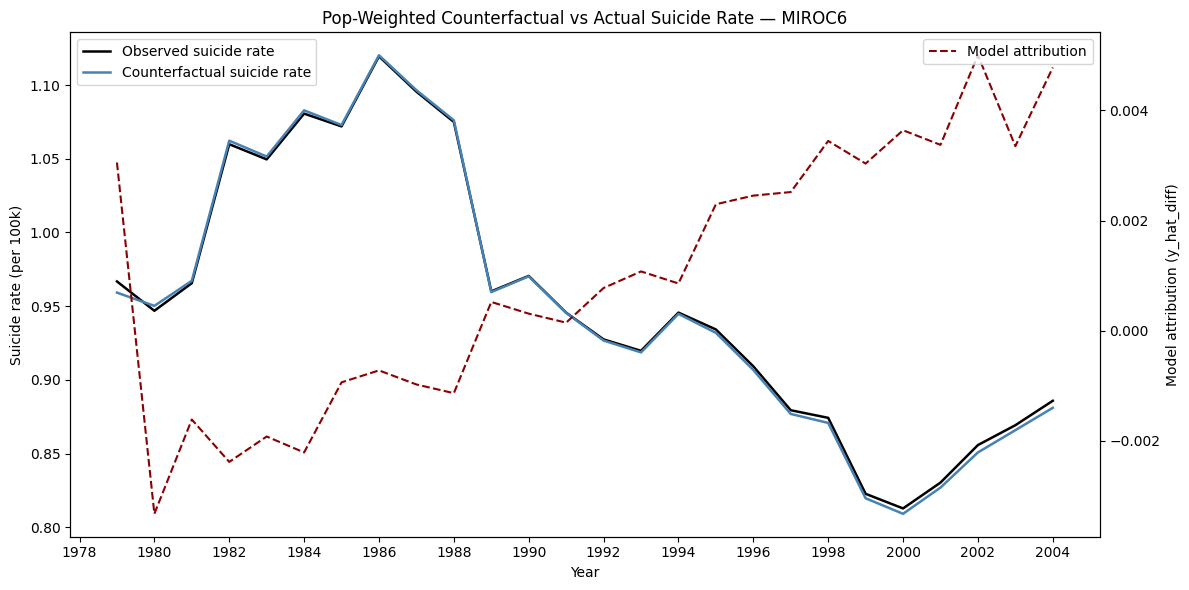

Generating plot for model: ACCESS-ESM1-5
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


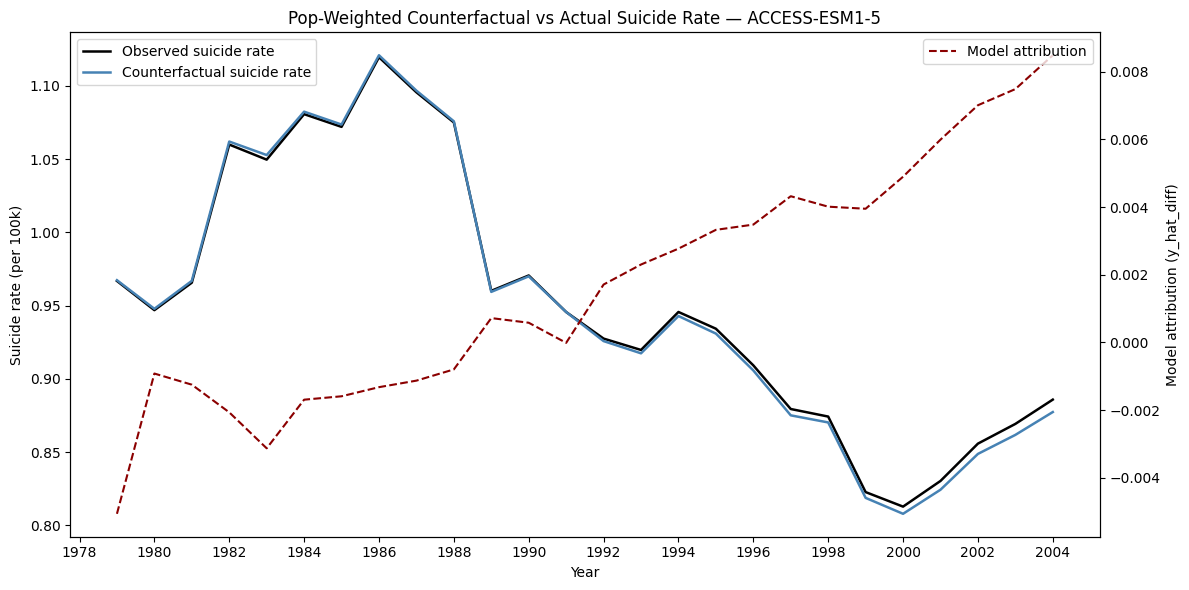

Generating plot for model: CanESM5
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


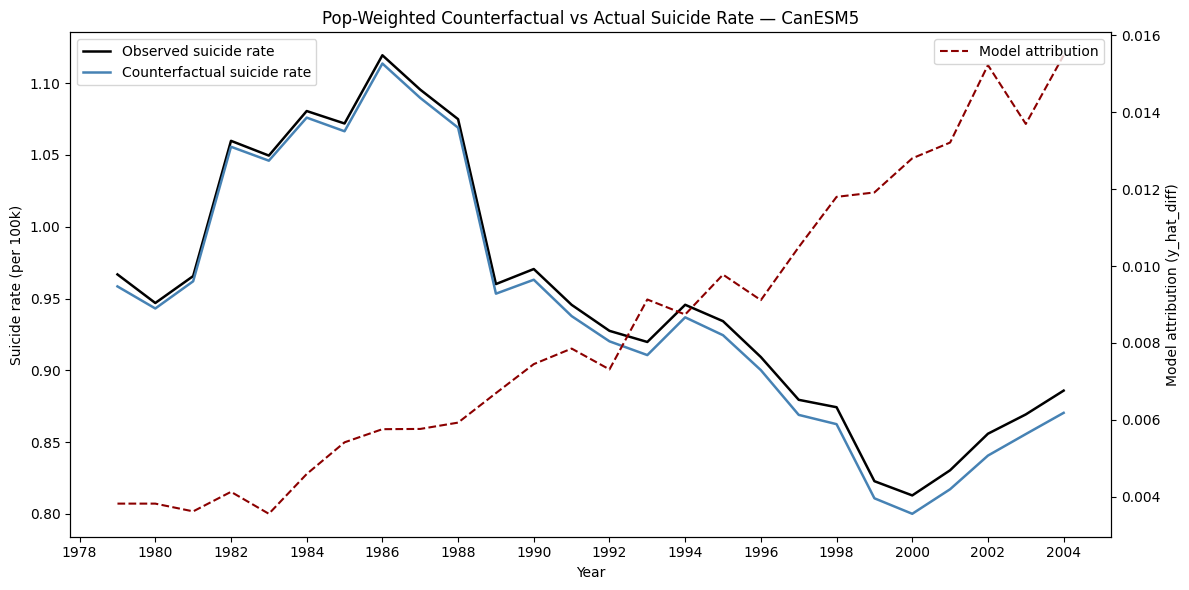

Generating plot for model: MRI-ESM2-0
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


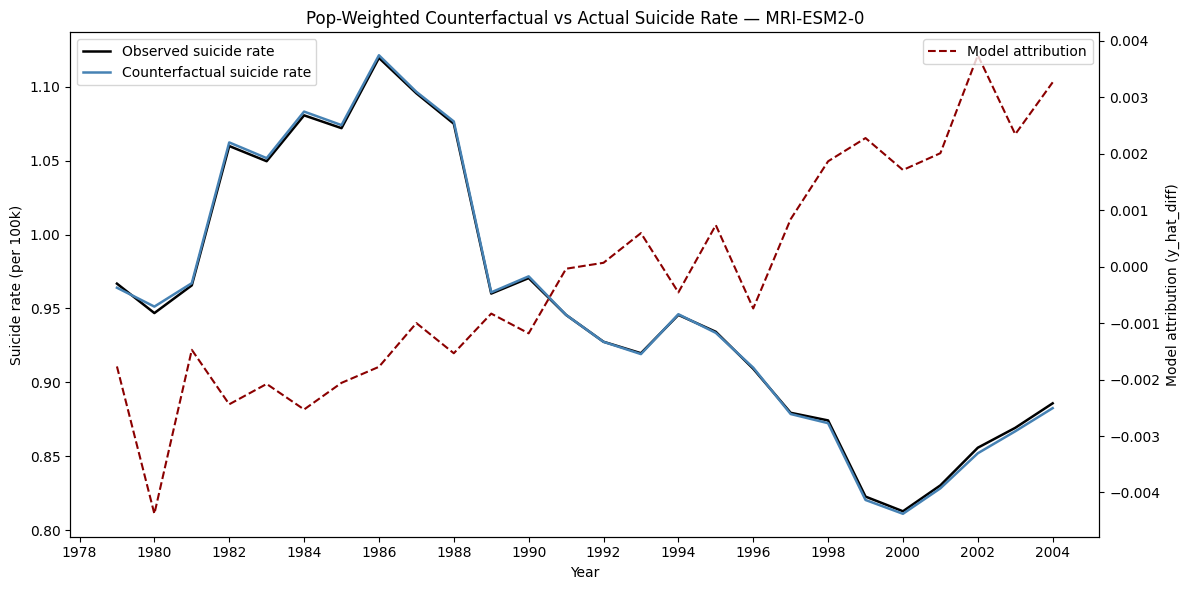

Generating plot for model: NorESM2-LM
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


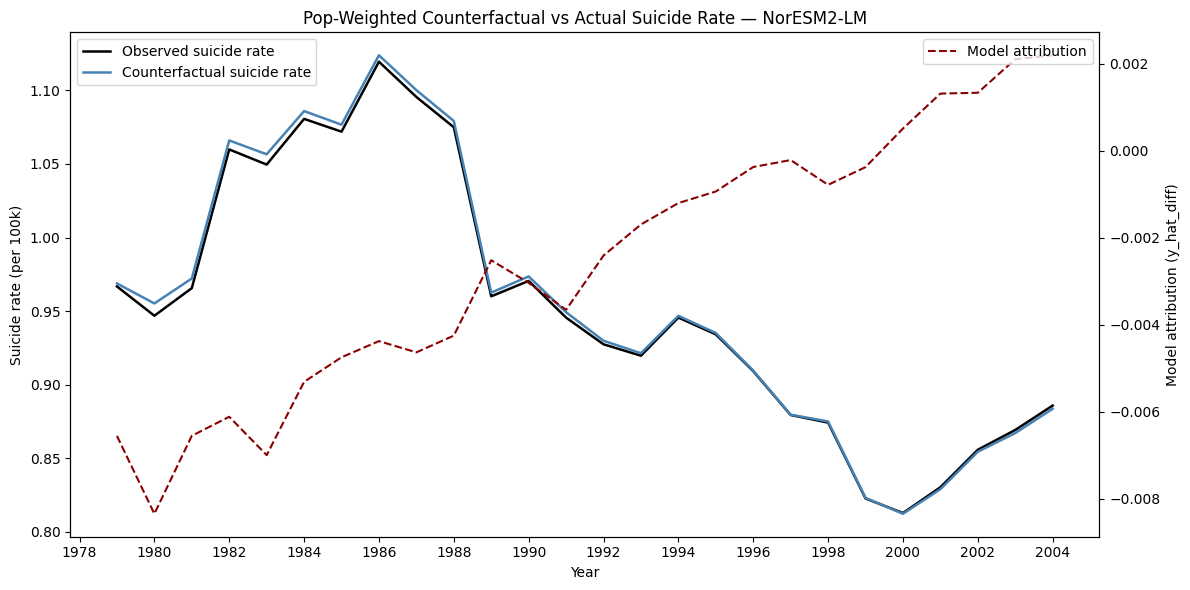

Generating plot for model: ACCESS-CM2
Running filter_and_avg for value_col = 'suiciderate' (agg_method = mean, pop_col = population)
Dropped 1680 rows due to NA in suiciderate or population
Running filter_and_avg for value_col = 'cfsuiciderate_attr' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in cfsuiciderate_attr or population
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = population)
Dropped 7169 rows due to NA in y_hat_diff or population


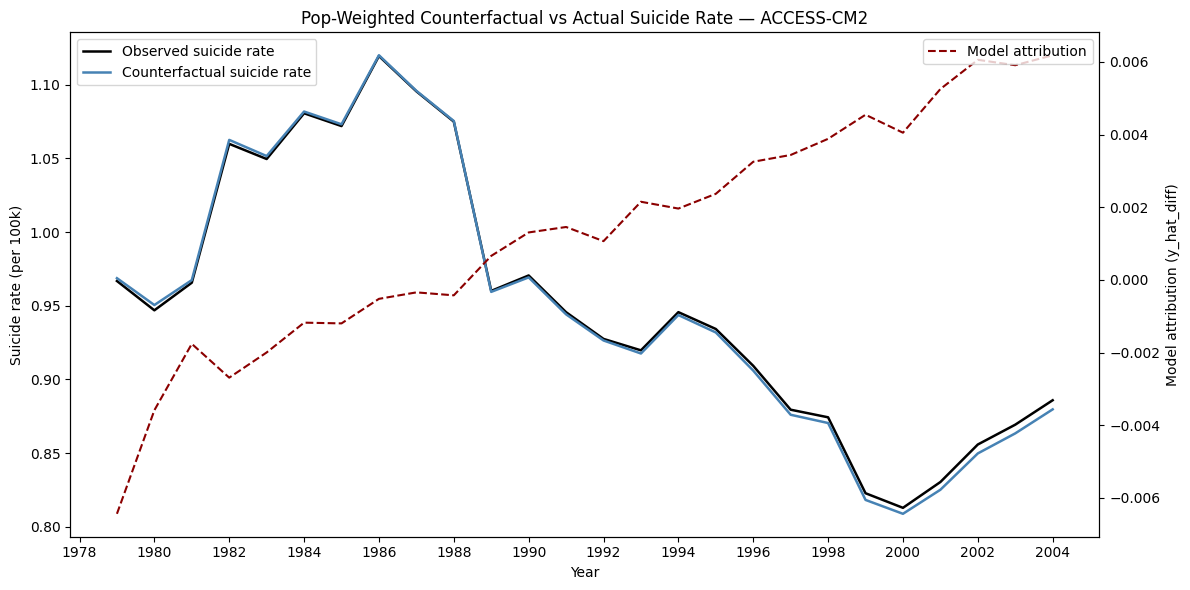

In [87]:
for model in models:
    plot_cf_timeseries(
        model=model,
        title=f"Pop-Weighted Counterfactual vs Actual Suicide Rate — {model}",
        pop_col="population"
    )


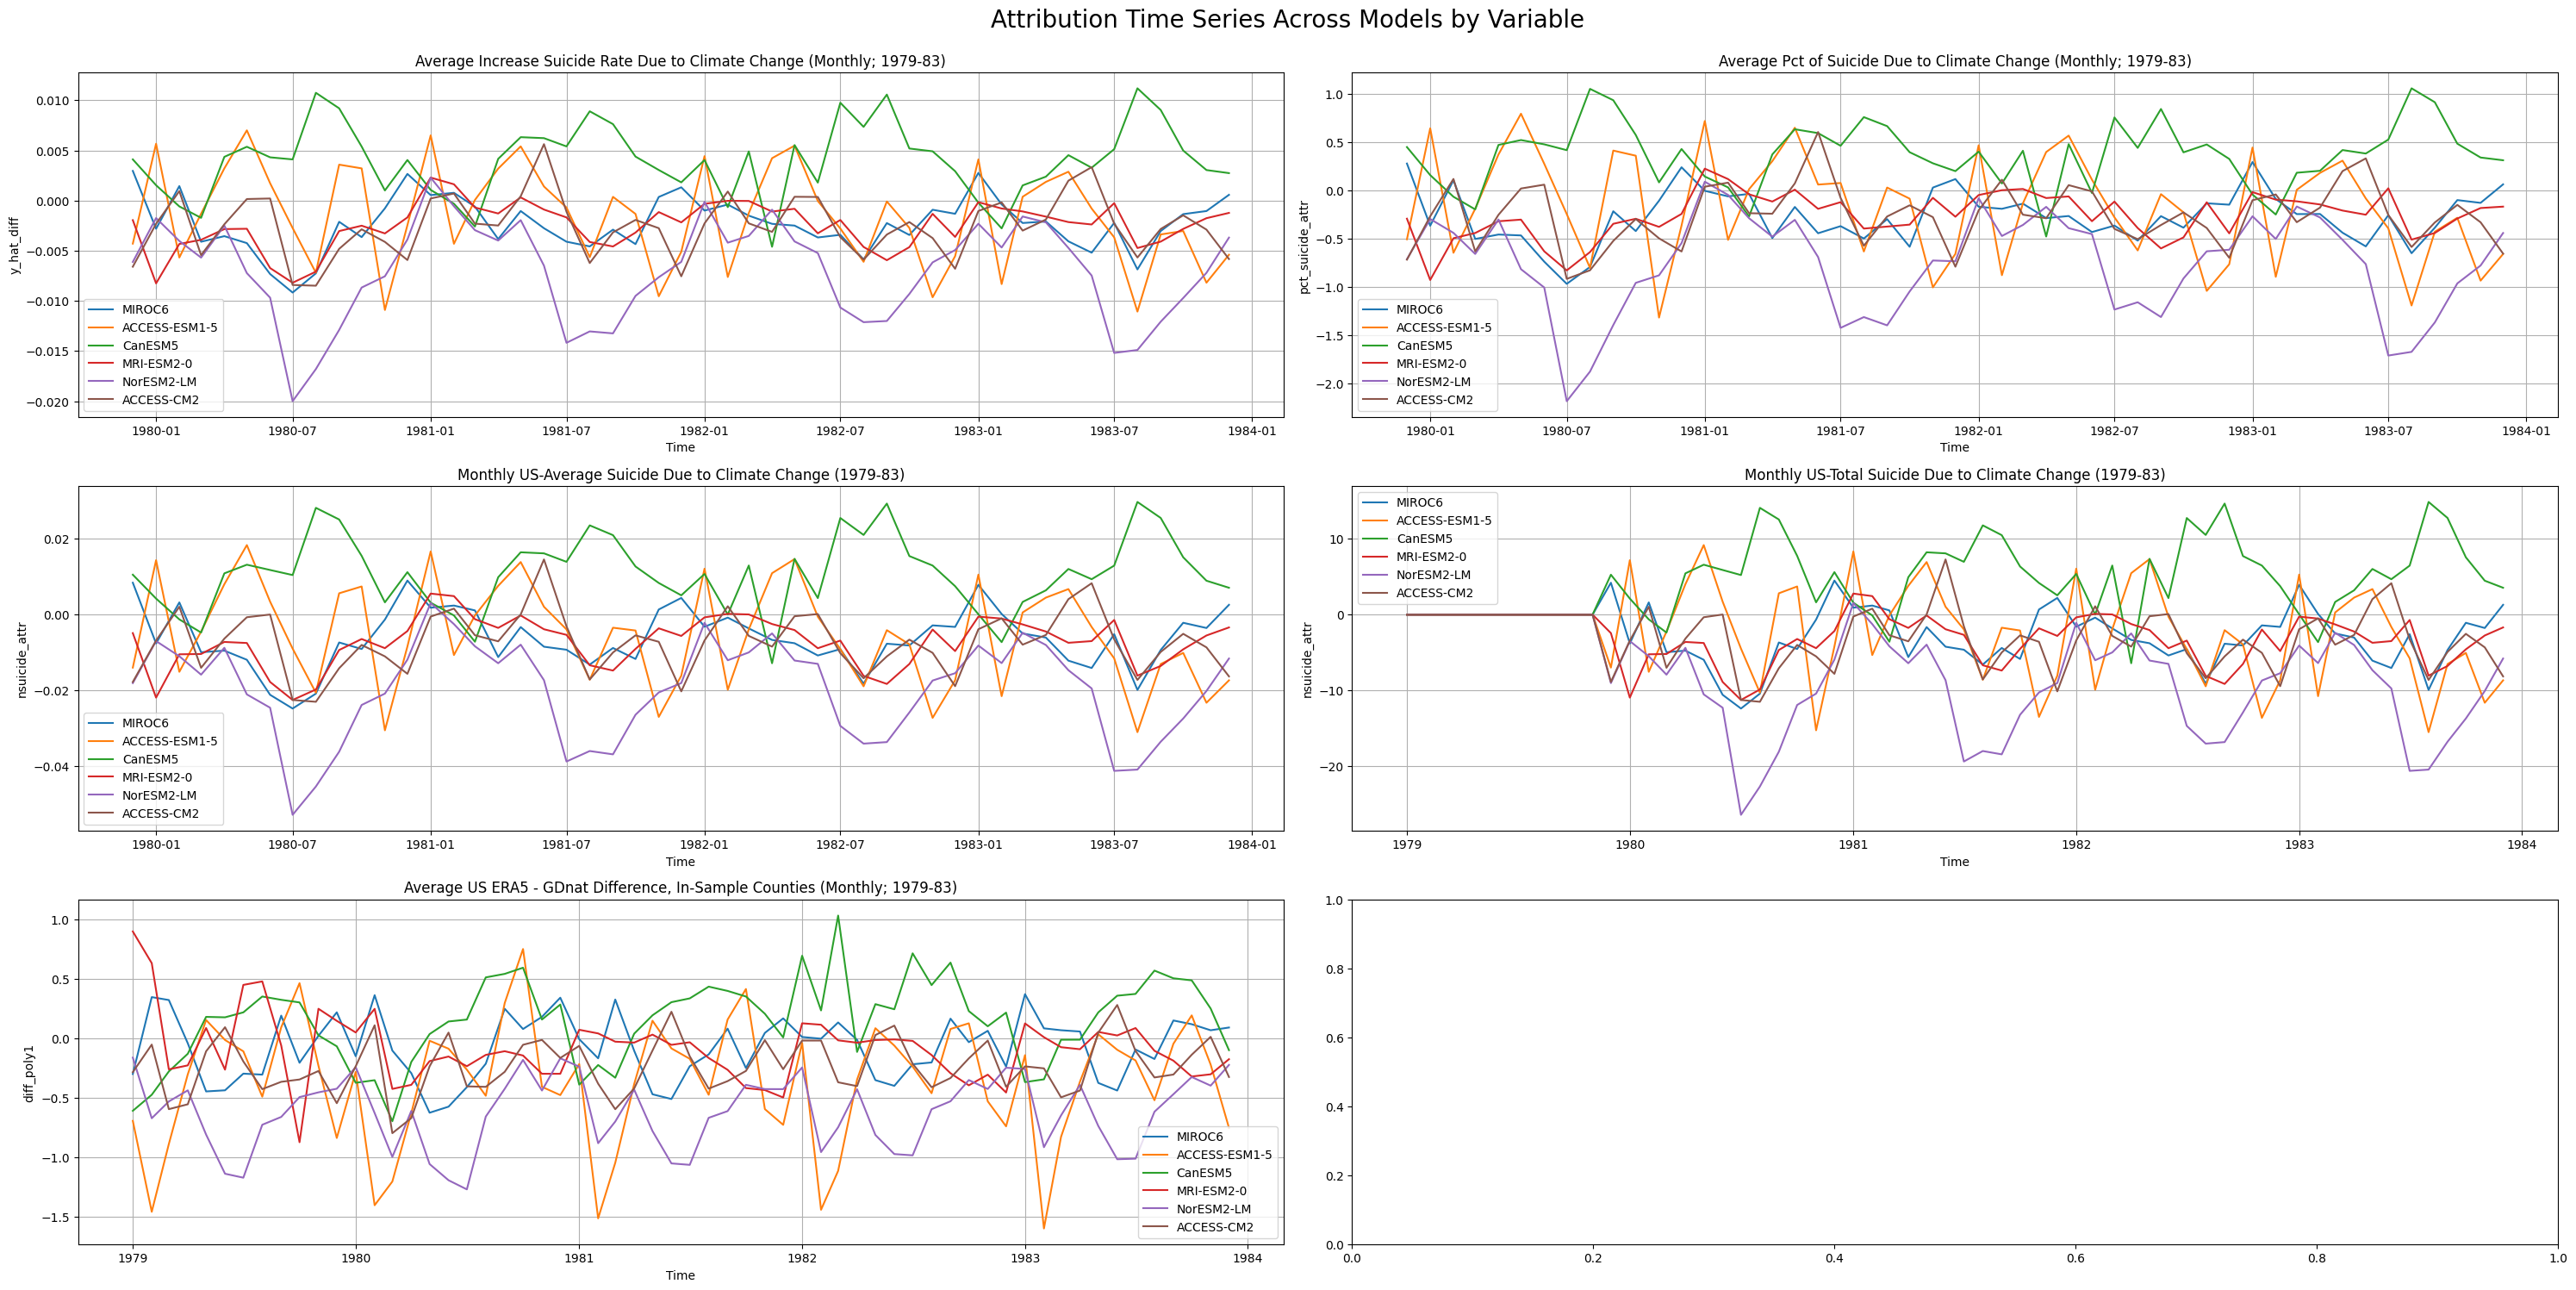

In [97]:
plot_params_list = [
    dict(
        value_col="y_hat_diff",
        time_agg_method=None,
        county_agg_method="average",
        title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979-83)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        title="Average Pct of Suicide Due to Climate Change (Monthly; 1979-83)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        title="Monthly US-Average Suicide Due to Climate Change (1979-83)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="sum",
        title="Monthly US-Total Suicide Due to Climate Change (1979-83)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method=None,
        county_agg_method="average",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 1979-83)"
    ),
]

fig, axs = plt.subplots(3, 2, figsize=(30, 15))
axs = axs.flatten()

for ax, params in zip(axs, plot_params_list):
    for model in models:
        try:
            plot_time_series_all_models(
                models=[model],  # plot only one model at a time on this ax
                value_col=params["value_col"],
                time_agg_method=params["time_agg_method"],
                county_agg_method=params["county_agg_method"],
                start_date="197901",
                end_date="198312",
                y_range=None,
                title="",  # no title per model here
                ax=ax  # pass current subplot axis
            )
        except Exception as e:
            print(f"Error plotting model {model} for {params['value_col']}: {e}")

    ax.set_title(params["title"])
    ax.legend(models)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle("Attribution Time Series Across Models by Variable", fontsize=20, y=0.995)
plt.show()


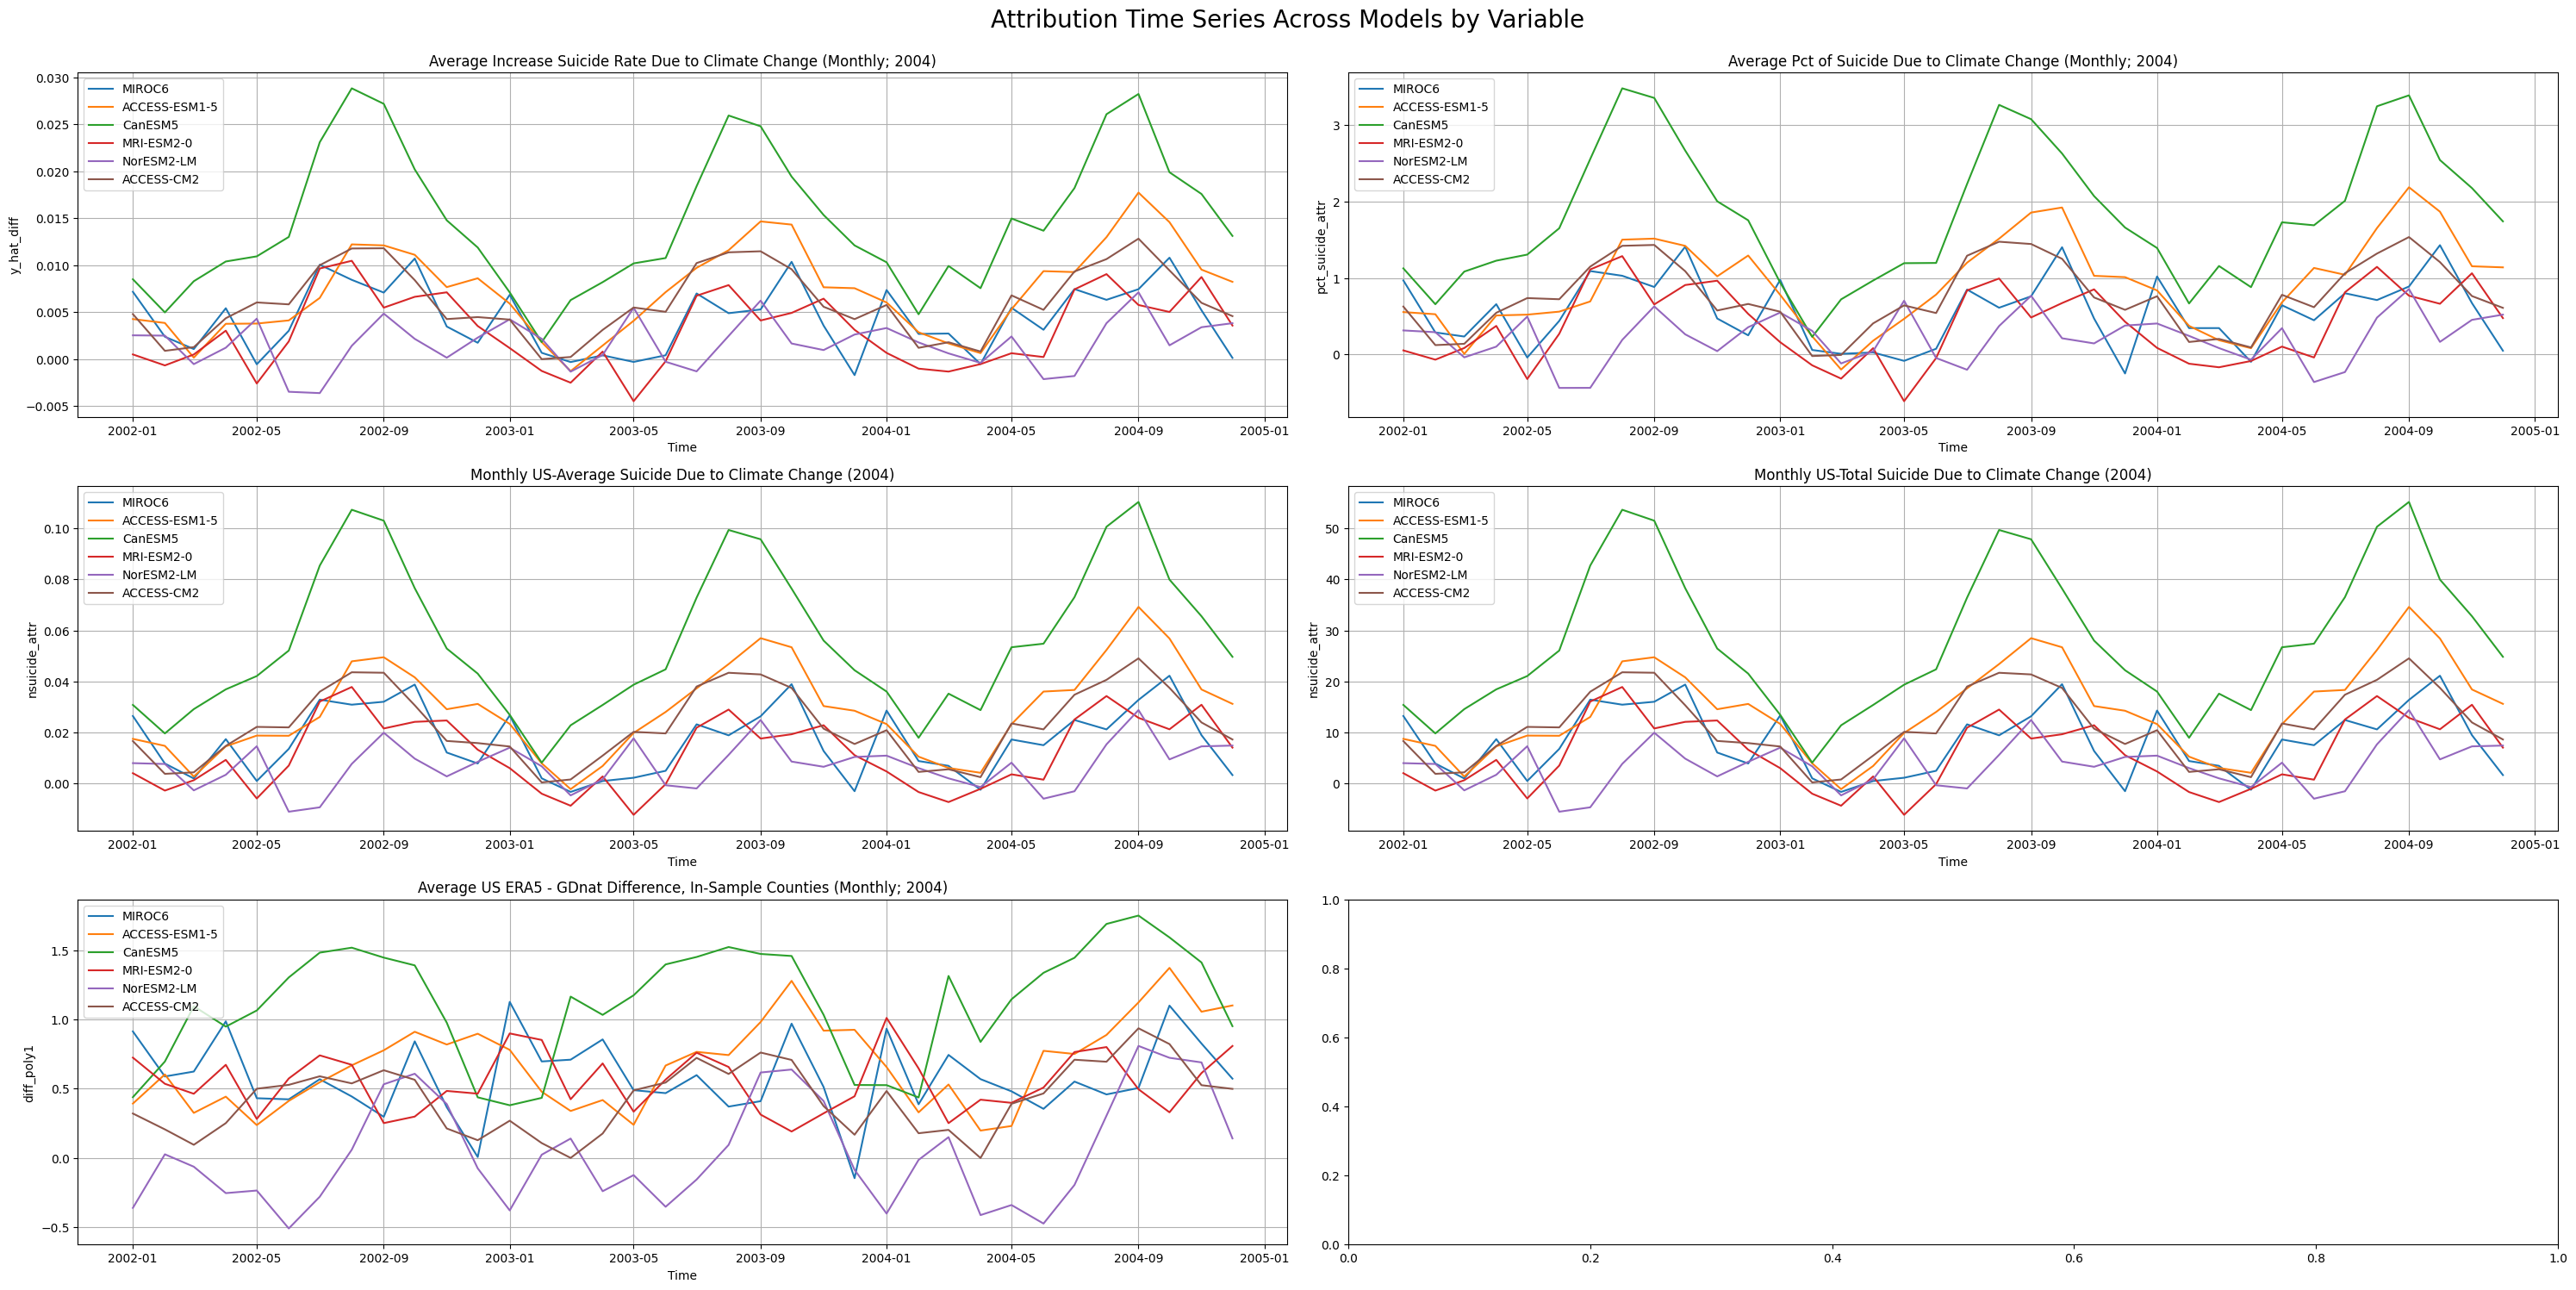

In [95]:
plot_params_list = [
    dict(
        value_col="y_hat_diff",
        time_agg_method=None,
        county_agg_method="average",
        title="Average Increase Suicide Rate Due to Climate Change (Monthly; 2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        title="Average Pct of Suicide Due to Climate Change (Monthly; 2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        title="Monthly US-Average Suicide Due to Climate Change (2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="sum",
        title="Monthly US-Total Suicide Due to Climate Change (2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method=None,
        county_agg_method="average",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 2004)"
    ),
]

fig, axs = plt.subplots(3, 2, figsize=(30, 15))
axs = axs.flatten()

for ax, params in zip(axs, plot_params_list):
    for model in models:
        try:
            plot_time_series_all_models(
                models=[model],  # plot only one model at a time on this ax
                value_col=params["value_col"],
                time_agg_method=params["time_agg_method"],
                county_agg_method=params["county_agg_method"],
                start_date="200201",
                end_date="200412",
                y_range=None,
                title="",  # no title per model here
                ax=ax  # pass current subplot axis
            )
        except Exception as e:
            print(f"Error plotting model {model} for {params['value_col']}: {e}")

    ax.set_title(params["title"])
    ax.legend(models)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle("Attribution Time Series Across Models by Variable", fontsize=20, y=0.995)
plt.show()


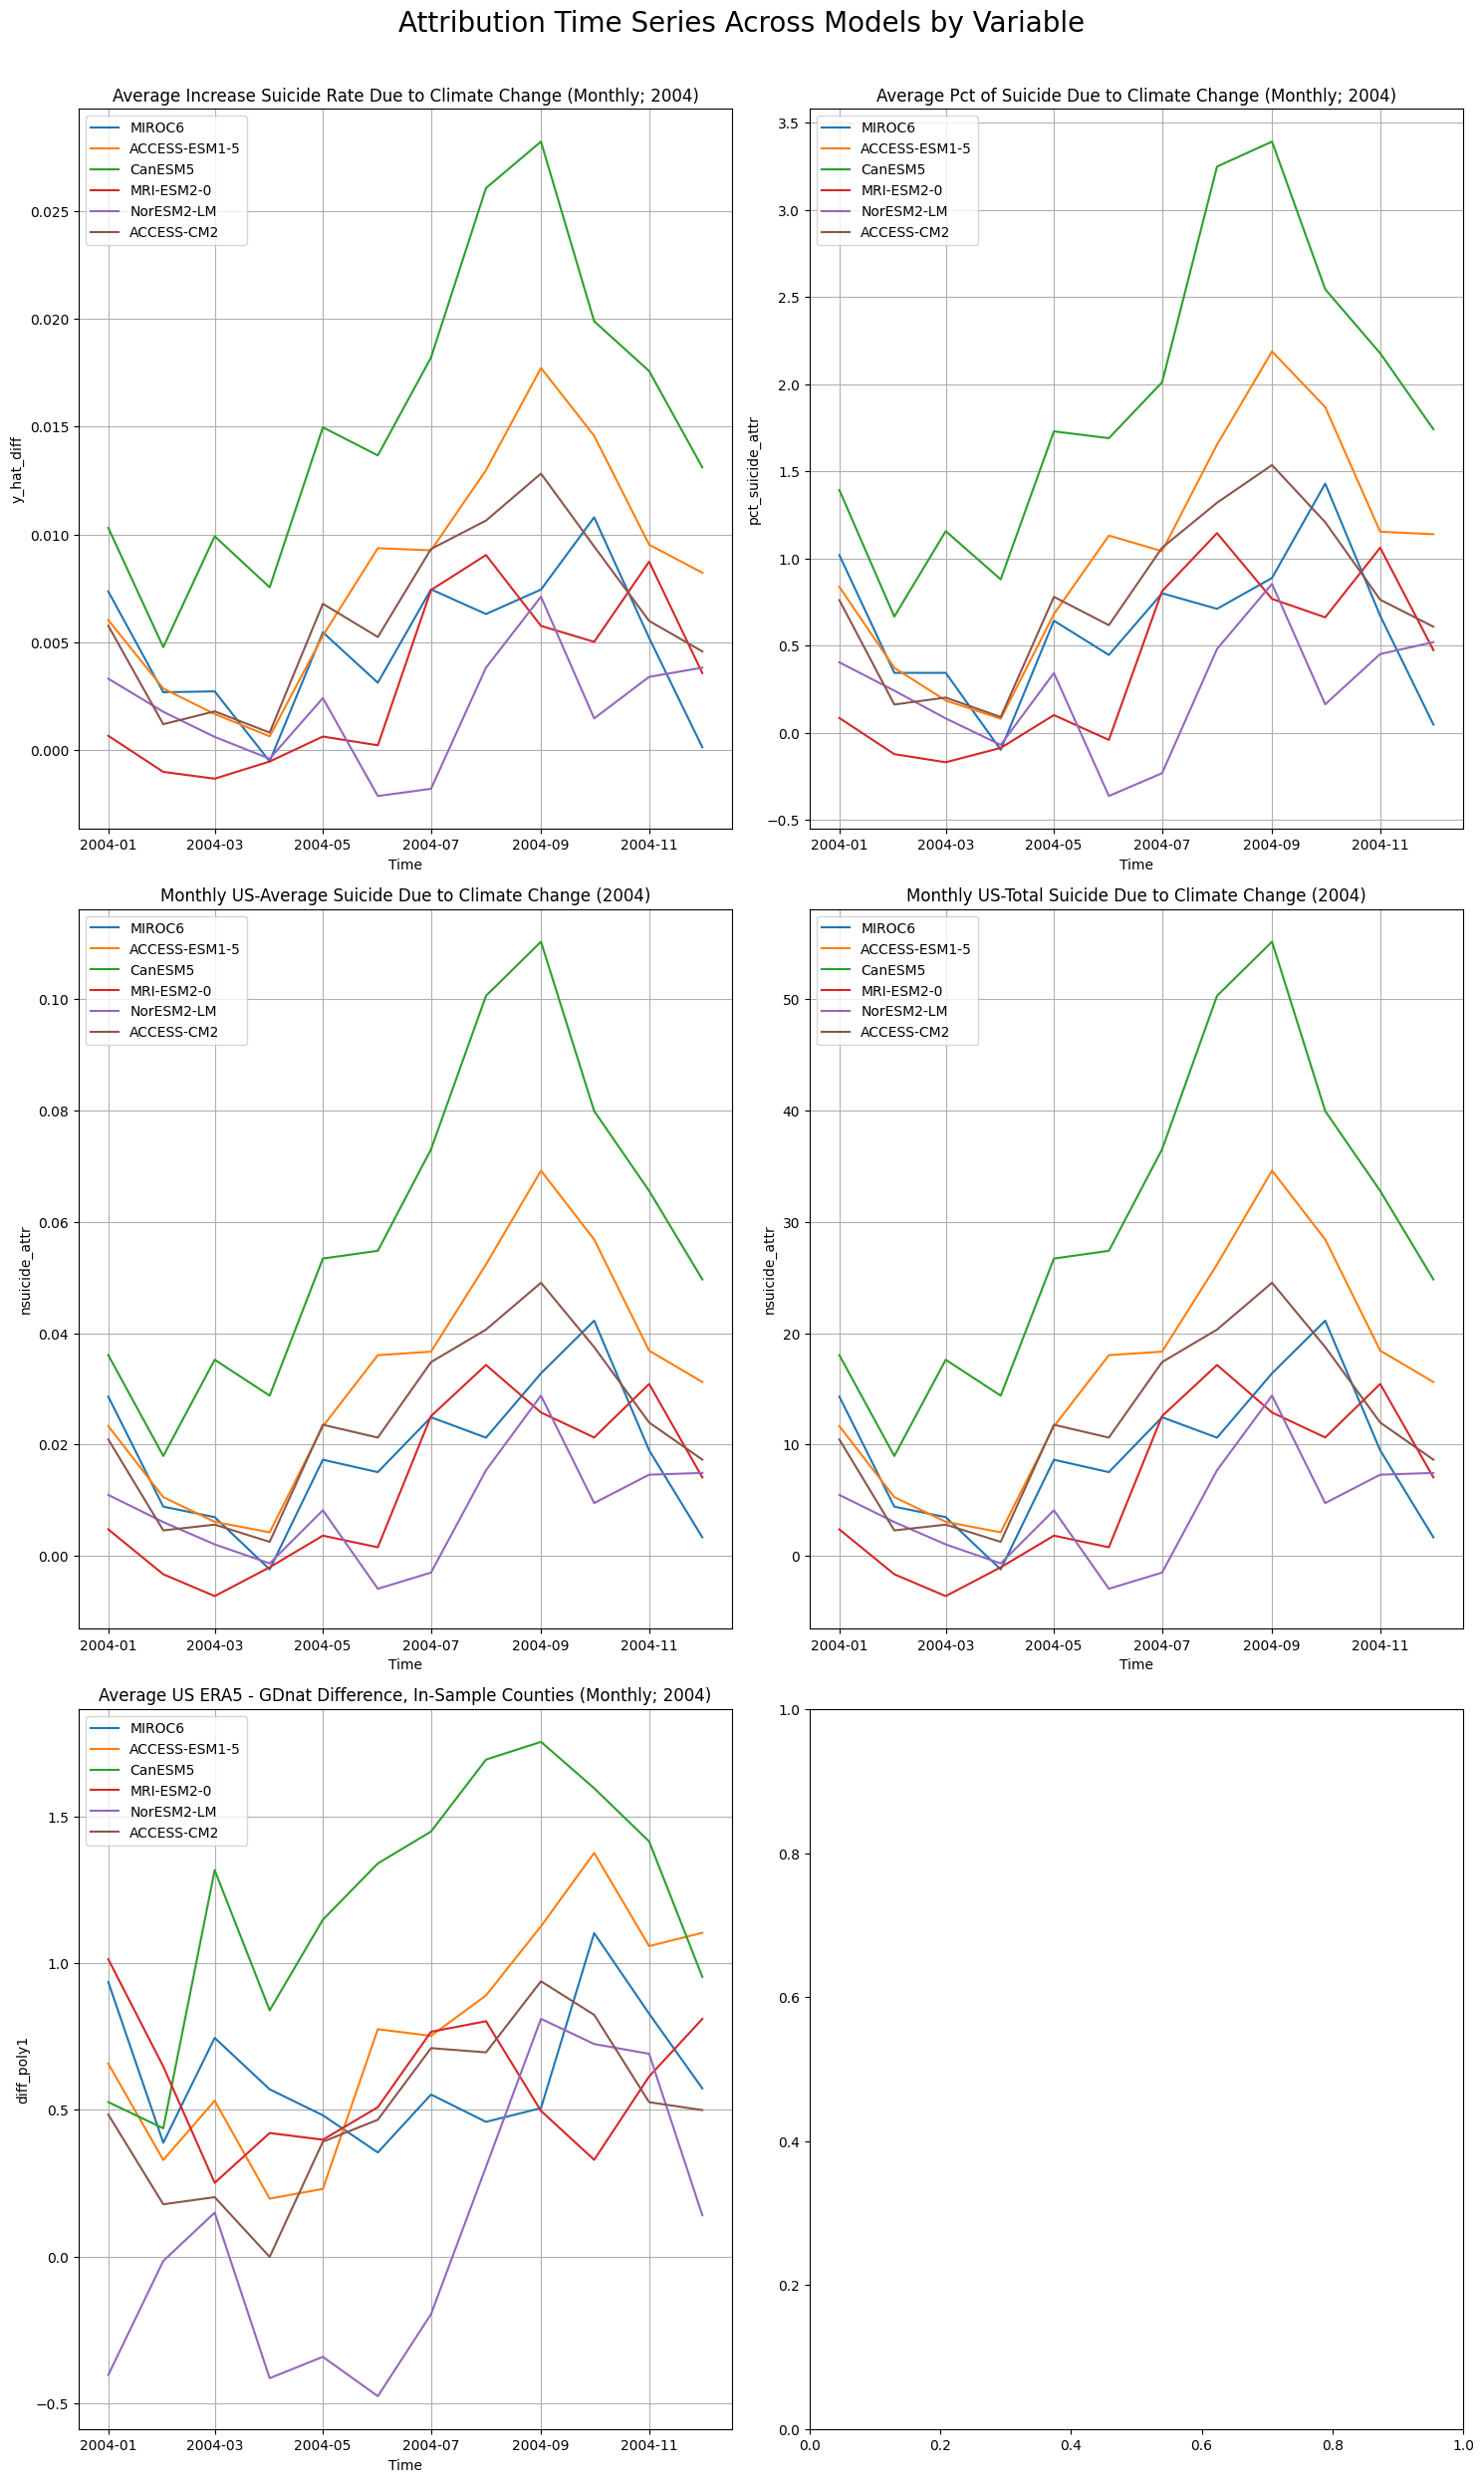

In [92]:
plot_params_list = [
    dict(
        value_col="y_hat_diff",
        time_agg_method=None,
        county_agg_method="average",
        start_date="200401",
        end_date="200412",
        title="Average Increase Suicide Rate Due to Climate Change (Monthly; 2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="200401",
        end_date="200412",
        title="Average Pct of Suicide Due to Climate Change (Monthly; 2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="200401",
        end_date="200412",
        title="Monthly US-Average Suicide Due to Climate Change (2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="sum",
        start_date="200401",
        end_date="200412",
        title="Monthly US-Total Suicide Due to Climate Change (2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method=None,
        county_agg_method="average",
        start_date="200401",
        end_date="200412",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 2004)"
    ),
]

fig, axs = plt.subplots(3, 2, figsize=(15, 25))
axs = axs.flatten()

for ax, params in zip(axs, plot_params_list):
    for model in models:
        try:
            plot_time_series_all_models(
                models=[model],  # plot only one model at a time on this ax
                value_col=params["value_col"],
                time_agg_method=params["time_agg_method"],
                county_agg_method=params["county_agg_method"],
                start_date=params["start_date"],
                end_date=params["end_date"],
                y_range=None,
                title="",  # no title per model here
                ax=ax  # pass current subplot axis
            )
        except Exception as e:
            print(f"Error plotting model {model} for {params['value_col']}: {e}")

    ax.set_title(params["title"])
    ax.legend(models)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle("Attribution Time Series Across Models by Variable", fontsize=20, y=0.995)
plt.show()


Error plotting model ACCESS-ESM1-5 for pct_suicide_attr: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.


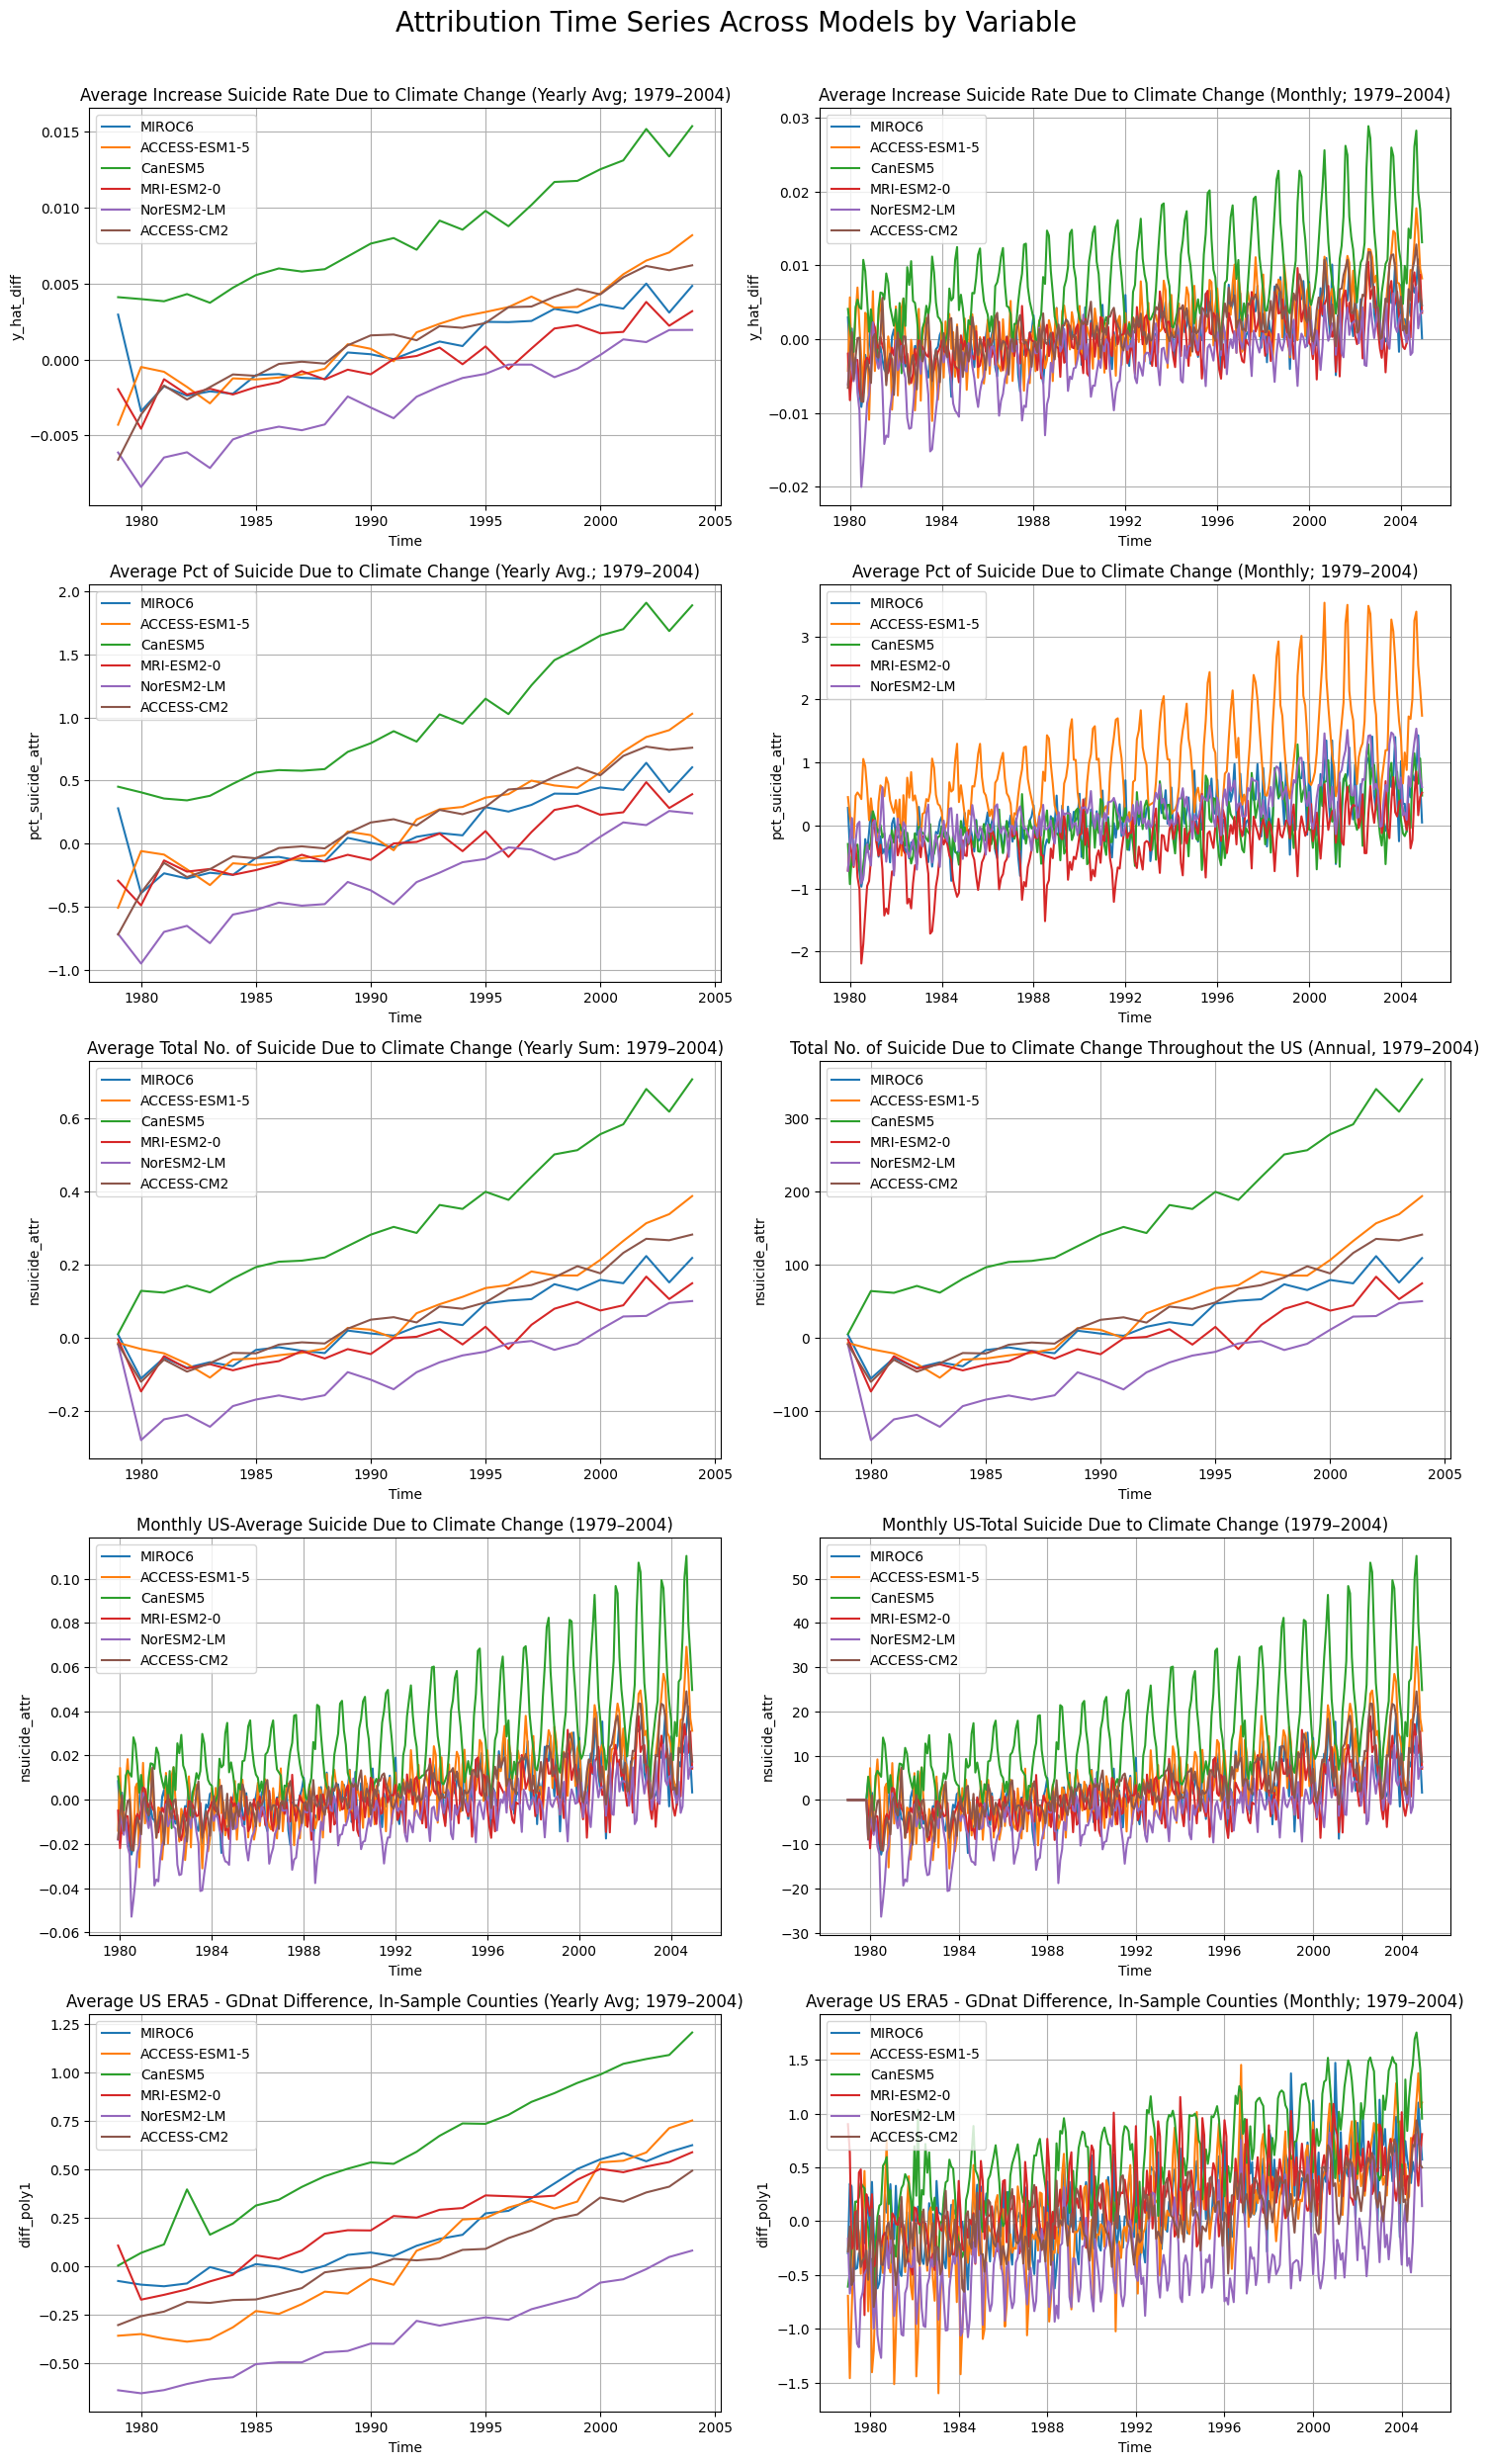

In [88]:
plot_params_list = [
    dict(
        value_col="y_hat_diff",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Increase Suicide Rate Due to Climate Change (Yearly Avg; 1979–2004)"
    ),
    dict(
        value_col="y_hat_diff",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979–2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Pct of Suicide Due to Climate Change (Yearly Avg.; 1979–2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method="sum",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Total No. of Suicide Due to Climate Change (Yearly Sum: 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method="sum",
        county_agg_method="sum",
        start_date="197901",
        end_date="200412",
        title="Total No. of Suicide Due to Climate Change Throughout the US (Annual, 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Monthly US-Average Suicide Due to Climate Change (1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="sum",
        start_date="197901",
        end_date="200412",
        title="Monthly US-Total Suicide Due to Climate Change (1979–2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Yearly Avg; 1979–2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 1979–2004)"
    ),
]

fig, axs = plt.subplots(5, 2, figsize=(15, 25))
axs = axs.flatten()

for ax, params in zip(axs, plot_params_list):
    for model in models:
        try:
            plot_time_series_all_models(
                models=[model],  # plot only one model at a time on this ax
                value_col=params["value_col"],
                time_agg_method=params["time_agg_method"],
                county_agg_method=params["county_agg_method"],
                start_date=params["start_date"],
                end_date=params["end_date"],
                y_range=None,
                title="",  # no title per model here
                ax=ax  # pass current subplot axis
            )
        except Exception as e:
            print(f"Error plotting model {model} for {params['value_col']}: {e}")

    ax.set_title(params["title"])
    ax.legend(models)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.suptitle("Attribution Time Series Across Models by Variable", fontsize=20, y=0.995)
plt.show()


In [ ]:
plot_params_list = [
    dict(
        value_col="y_hat_diff",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Increase Suicide Rate Due to Climate Change (Yearly Avg; 1979–2004)"
    ),
    dict(
        value_col="y_hat_diff",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979–2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Pct of Suicide Due to Climate Change (Yearly Avg.; 1979–2004)"
    ),
    dict(
        value_col="pct_suicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method="sum",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average Total No. of Suicide Due to Climate Change (Yearly Sum: 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method="sum",
        county_agg_method="sum",
        start_date="197901",
        end_date="200412",
        title="Total No. of Suicide Due to Climate Change Throughout the US (Annual, 1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Monthly US-Average Suicide Due to Climate Change (1979–2004)"
    ),
    dict(
        value_col="nsuicide_attr",
        time_agg_method=None,
        county_agg_method="sum",
        start_date="197901",
        end_date="200412",
        title="Monthly US-Total Suicide Due to Climate Change (1979–2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method="average",
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Yearly Avg; 1979–2004)"
    ),
    dict(
        value_col="diff_poly1",
        time_agg_method=None,
        county_agg_method="average",
        start_date="197901",
        end_date="200412",
        title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 1979–2004)"
    ),
]

# Loop through and plot each
for params in plot_params_list:
    plot_time_series_all_models(
        models=models,
        **params
    )


In [ ]:
plot_time_series_all_models(
    models=models,
    value_col="diff_poly1",
    time_agg_method="average",      # "average" or "sum" over years
    county_agg_method="average",    # "average" or "sum" across counties               
    start_date="197901",
    end_date="200412",
    title="First-order average effect over time by model"
)


In [ ]:
for model in models:

    fig, axs = plt.subplots(5, 2, figsize=(15, 25))
    axs = axs.flatten()  # flatten for easy indexing

    dataset_filepath = config.get_combined_fullsample_attr(model=model)
    print(f"Plotting time series for model: {model}")

    # List of your plot parameters (one dict per plot)
    plot_params = [
        dict(
            dataset_fp= dataset_filepath,
            column_to_plot="y_hat_diff",
            time_agg_method="average",
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average Increase Suicide Rate Due to Climate Change (Yearly Avg; 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="y_hat_diff",
            time_agg_method=None,
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=False,
            title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="pct_suicide_attr",
            time_agg_method="average",
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average Pct of Suicide Due to Climate Change (Yearly Avg.; 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="pct_suicide_attr",
            time_agg_method=None,
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="nsuicide_attr",
            time_agg_method="sum",
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average Total No. of Suicide Due to Climate Change (Yearly Sum: 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="nsuicide_attr",
            time_agg_method="sum",
            year_range=(1979, 2004),
            county_agg_method="sum",
            plot_all_counties=False,
            title="Total No. of Suicide Due to Climate Change Throughout the US (Annual, 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="nsuicide_attr",
            time_agg_method=None,
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Monthly US-Average Suicide Due to Climate Change (1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="nsuicide_attr",
            time_agg_method=None,
            year_range=(1979, 2004),
            county_agg_method="sum",
            plot_all_counties=False,
            title="Monthly US-Total Suicide Due to Climate Change (1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="diff_poly1",
            time_agg_method="average",
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average US ERA5 - GDnat Difference, In-Sample Counties (Yearly Avg; 1979–2004)"
        ),
        dict(
            dataset_fp=dataset_filepath,
            column_to_plot="diff_poly1",
            time_agg_method=None,
            year_range=(1979, 2004),
            county_agg_method="average",
            plot_all_counties=True,
            title="Average US ERA5 - GDnat Difference, In-Sample Counties (Monthly; 1979–2004)"
        )
    ]

    # Loop over axes and plot parameters
    for ax, params in zip(axs, plot_params):
        plot_time_series_attr(ax=ax, **params)

    plt.tight_layout()
    plt.suptitle(f"Attribution Time Series – {model}", fontsize=20, y=1.02)
    plt.show()


{
        "value_col": "nsuicide_attr",
        "county_data_path": config.COMBINED_FILTERED_ATTR,
        "title": "Suicide Number Attr (Sum, 2000–2004)",
        # "vmin": -13, "vmax": 13,
        "agg_method": "sum"
    },
    {
        "value_col": "nsuicide_attr",
        "county_data_path": config.COMBINED_FILTERED_ATTR,
        "title": "Suicide Number Attr (Mean, 2000–2004)",
        # "vmin": -0.2, "vmax": 0.2
    },
    {
        "value_col": "pct_suicide_attr",
        "county_data_path": config.COMBINED_FILTERED_ATTR,
        "title": "% Suicide Attributable (2000–2004)",
        # "vmin": -2.2, "vmax": 2.2
    },
    {
        "value_col": "y_hat_diff",
        "county_data_path": config.CURRENT_TREND_ATTR,
        "title": "Suicide Rate Δ from Climate Change (2000–2004)",
        # "vmin": -0.01, "vmax": 0.01
    },
]


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="y_hat_diff",
    time_agg_method="average",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average Increase Suicide Rate Due to Climate Change (Yearly Avg; 1979–2004)"
)



In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="y_hat_diff",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    # plot_all_counties=True,
    title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="y_hat_diff",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average Increase Suicide Rate Due to Climate Change (Monthly; 1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="pct_suicide_attr",
    time_agg_method="average",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="pct_suicide_attr",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    # plot_all_counties=True,
    title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
)


In [ ]:
import pandas as pd
df = pd.read_csv(config.COMBINED_FULLSAMPLE_ATTR)

if "poly_id_int" in df.columns:
    num_unique_counties = df["poly_id_int"].nunique()
    print(f"Number of unique counties (poly_id_int): {num_unique_counties}")
else:
    print("Column 'poly_id_int' not found in the dataset.")


In [ ]:
config.COMBINED_FILTERED_ATTR

In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="pct_suicide_attr",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average Pct of Suicide Due to Climate Change (Monthly; 1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="nsuicide_attr",
    time_agg_method="sum",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    # plot_all_counties=True,
    title="Average Total No. of Suicide Due to Climate Change (1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="nsuicide_attr",
    time_agg_method="sum",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="sum",
    # plot_all_counties=True,
    title="US Annual Sum of Suicides Due to Climate Change (1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="nsuicide_attr",
    time_agg_method="average",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Annual Average No. of Suicide Due to Climate Change (1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.COMBINED_FILTERED_ATTR,
    column_to_plot="nsuicide_attr",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Monthly Average No. of Suicide Due to Climate Change (1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.CURRENT_TREND_ATTR,
    column_to_plot="diff_poly1",
    time_agg_method="average",
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average US ERA5 - GDnat Difference, All Counties (Yearly Avg; 1979–2004)"
)


In [ ]:
plot_time_series_attr(
    dataset_fp=config.CURRENT_TREND_ATTR,
    column_to_plot="diff_poly1",
    time_agg_method=None,
    year_range=(1979, 2004),
    # y_range=(0, 20),
    # county_code=6089,
    county_agg_method="average",
    plot_all_counties=True,
    title="Average US ERA5 - GDnat Difference, All Counties (Monthly; 1979–2004)"
)


### US Maps

plotting for path:  /global/scratch/projects/co_carleton/carleton_colab/projects/global_suicide/results/MIROC6/attribution_output_MIROC6.csv
[1/6] Loading shapefile...
[2/6] Loading county-level data...
❌ Error loading county-level data: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.
plotting for path:  /global/scratch/projects/co_carleton/carleton_colab/projects/global_suicide/results/ACCESS-ESM1-5/attribution_output_ACCESS-ESM1-5.csv
[1/6] Loading shapefile...
[2/6] Loading county-level data...
[3/6] Validating column names...
[4/6] Filtering and averaging data...
Running filter_and_avg for value_col = 'y_hat_diff' (agg_method = mean, pop_col = None)
Filtering data between 2000 and 2004 on column 'year'...
Aggregating using MEAN...
[5/6] Merging county data with shapefile...
Error plotting ACCESS-ESM1-5 for theme 'y_hat_diff': 'poly_id_int'
plotting for path:  /global/scratch/projects/co_carleton/carleton_colab/projects/global_suicide/resu

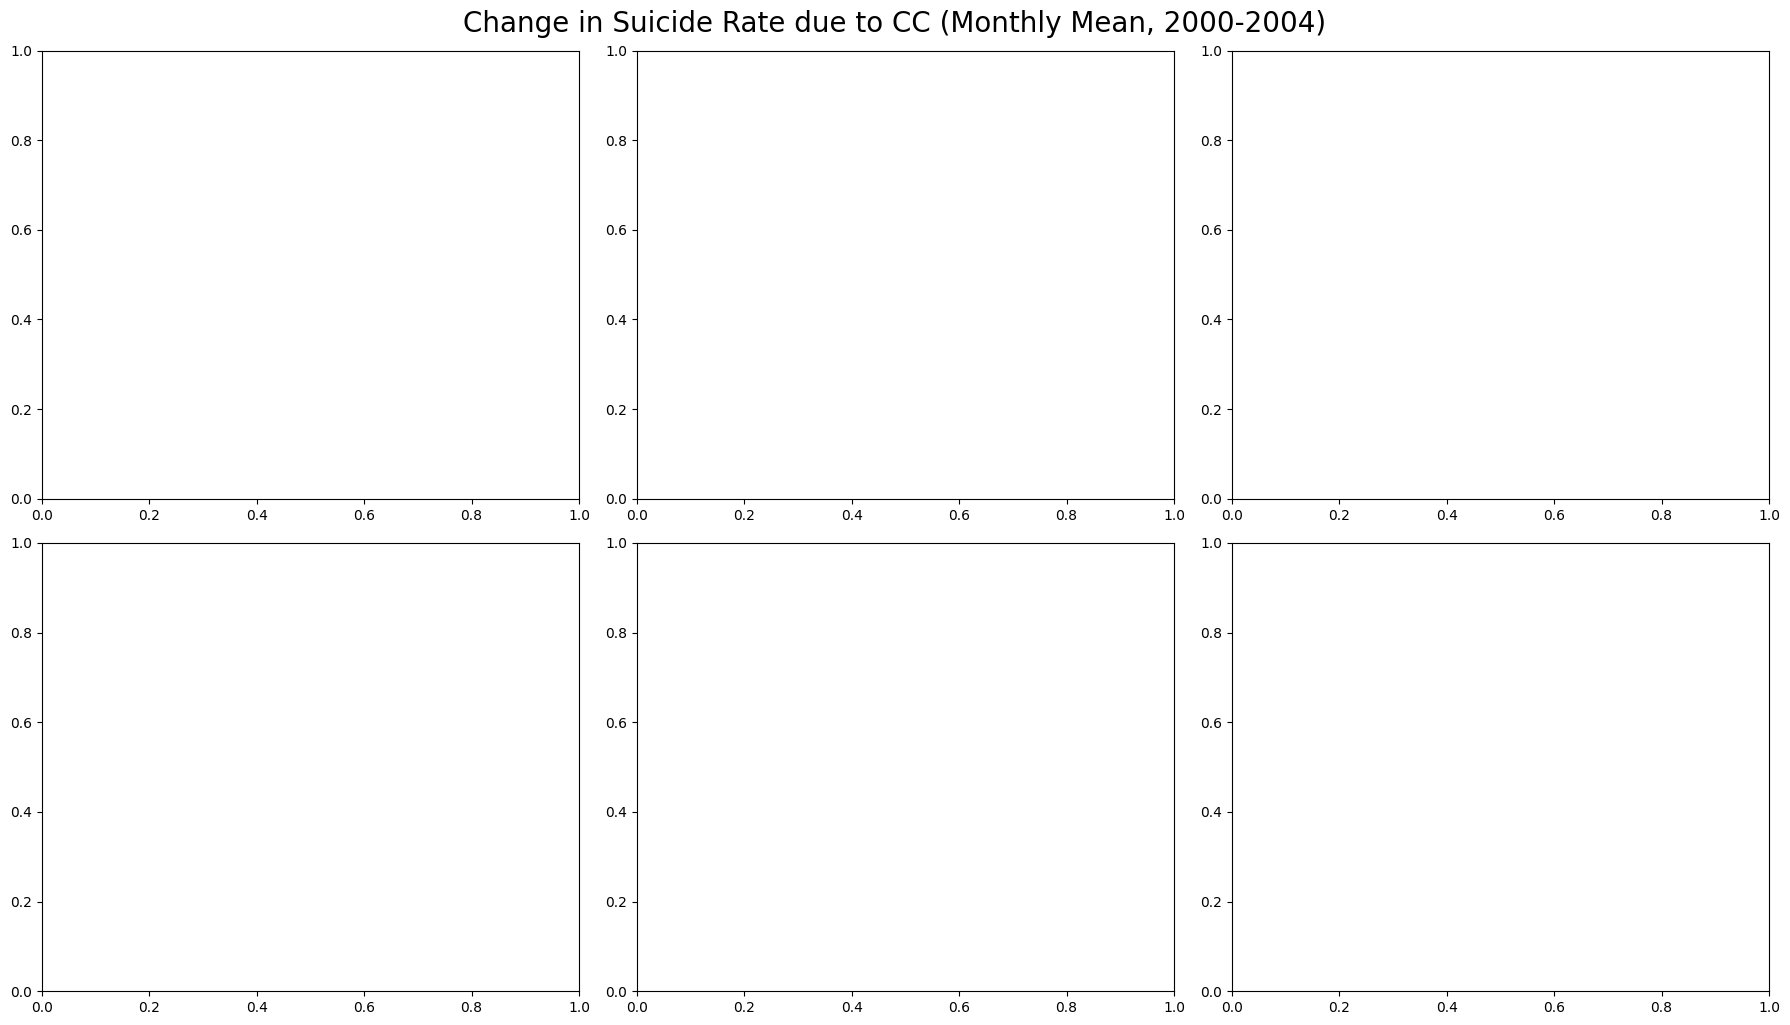

In [89]:
# only diff suicide rate 
themes = [
    {
        "value_col": "y_hat_diff",
        "title_template": "{model}",
        "title": "Change in Suicide Rate due to CC (Monthly Mean, 2000-2004)",
        "vmin": -.025, 
        "vmax": .025
    },
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            county_data_path = config.get_attribution_output_fp(model)

        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:

            print("plotting for path: ", county_data_path)
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# only diff suicide rate 
themes = [
    {
        "value_col": "y_hat_diff",
        "title_template": "{model}",
        "title": "Change in Suicide Rate due to CC (Monthly Mean, 2000-2004)"
    },
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            county_data_path = config.get_attribution_output_fp(model)

        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:

            print("plotting for path: ", county_data_path)
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# By Theme Plotting - Custom scales 
themes = [
    {
        "value_col": "diff_poly1",
        "title_template": "{model}",
        "title": "Average Temperature Difference (°C) Between ERA5 and GDNat, by model (2000–2004)",
        "vmin": -1.75,
        "vmax": 1.75
    },
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "sum",
        "title": "Total Number of Suicides Attributable, by model (2000-2004)",
        "vmin": -10,
        "vmax": 10
    },
    {
        "value_col": "pct_suicide_attr",
        "title_template": "{model}",
        "title": "Pct Suicides Attributed (Monthly Mean, 2000-2004)",
        "vmin": -2,
        "vmax": 2
    },
    {
        "value_col": "y_hat_diff",
        "title_template": "{model}",
        "title": "Change in Suicide Rate due to CC (Monthly Mean, 2000-2004)",
        "vmin": -.025,
        "vmax": .025
    },
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            print("USING OTHER DATASET")
            county_data_path = config.get_attribution_output_fp(model)
        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# Flexible 1%/5% cropped scales scales 
themes = [
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "sum",
        "title": "Total Number of Suicides Attributable, by model (2000-2004)",
        "crop_scale_pct": 1
    },
    {
        "value_col": "pct_suicide_attr",
        "title_template": "{model}",
        "title": "Pct Suicides Attributed (Monthly Mean, 2000-2004)",
        "crop_scale_pct": 5
    }
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            print("USING OTHER DATASET")
            county_data_path = config.get_combined_filtered_attr(model)
        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
                crop_scale_pct = theme.get("crop_scale_pct", None)
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# Frozen scales 
themes = [
    {
        "value_col": "diff_poly1",
        "title_template": "{model}",
        "title": "Average Temperature Difference (°C) Between ERA5 and GDNat, by model (2000–2004)",
        "vmin": -1.75,
        "vmax": 1.75
    },
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "sum",
        "title": "Total Number of Suicides Attributable, by model (2000-2004)",
        "vmin": -35,
        "vmax": 35
    },
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "mean",
        "title": "Monthly Suicides Attributed (Monthly Mean, 2000-2004)",
        "vmin": -0.6,
        "vmax": 0.6
    },
    {
        "value_col": "pct_suicide_attr",
        "title_template": "{model}",
        "title": "Pct Suicides Attributed (Monthly Mean, 2000-2004)",
        "vmin": -6,
        "vmax": 6
    },
    {
        "value_col": "y_hat_diff",
        "title_template": "{model}",
        "title": "Change in Suicide Rate due to CC (Monthly Mean, 2000-2004)"
    },
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            print("USING OTHER DATASET")
            county_data_path = config.get_combined_filtered_attr(model)
        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# Define the themes, each theme has a 'value_col' and a title template
themes = [
    {
        "value_col": "diff_poly1",
        "title_template": "{model}",
        "title": "Average Temperature Difference (°C) Between ERA5 and GDNat, by model (2000–2004)",
    },
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "sum",
        "title": "Total Number of Suicides Attributable, by model (2000-2004)",
    },
    {
        "value_col": "nsuicide_attr",
        "title_template": "{model}",
        "agg_method": "mean",
        "title": "Monthly Suicides Attributed (Monthly Mean, 2000-2004)",
    },
    {
        "value_col": "pct_suicide_attr",
        "title_template": "{model}",
        "title": "Pct Suicides Attributed (Monthly Mean, 2000-2004)",
    },
    {
        "value_col": "y_hat_diff",
        "title_template": "{model}",
        "title": "Change in Suicide Rate due to CC (Monthly Mean, 2000-2004)"
    },
]

for theme_idx, theme in enumerate(themes):
    n_models = len(models)
    ncols = 3
    nrows = (n_models + ncols - 1) // ncols  # ceil division for rows
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axs = axs.flatten()

    for i, model in enumerate(models):
        col = theme.get("value_col")
        if col == "y_hat_diff":
            county_data_path = config.get_combined_filtered_attr(model)
        else:
            county_data_path = config.get_combined_fullsample_attr(model)
        
        # Compose title for this subplot
        if "title_template" in theme:
            title = theme["title_template"].format(model=model)
        else:
            title = theme.get("title", "")
        
        try:
            functions.plot_county_data(
                ax=axs[i],
                shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
                shapefile_id_col="GEOID",
                county_data_path=county_data_path,
                county_id_col="poly_id_int",
                value_col=theme["value_col"],
                title=title,
                vmin=theme.get("vmin"),
                vmax=theme.get("vmax"),
                agg_method=theme.get("agg_method", "mean"),
                crop_bounds=[-125, -66.5, 24, 50],
                start_time=2000,
                end_time=2004,
                time_col="year",
                show=False,
            )
        except Exception as e:
            print(f"Error plotting {model} for theme '{theme['value_col']}': {e}")

    # Hide any unused axes (in case nrows*ncols > n_models)
    for j in range(n_models, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.suptitle(theme.get('title', ''), fontsize=20, y=1.02)
    plt.show()
    plt.close()


In [ ]:
# By model plotting - 6 subplots per model

models = ["MIROC6", "ACCESS-ESM1-5", "CanESM5", "MRI-ESM2-0", "NorESM2-LM", "ACCESS-CM2"]

for model in models:
    print(f"\nPlotting for model: {model}")
    
    # Use getter to retrieve file path for this model
    filtered_path = config.get_combined_fullsample_attr(model)
    
    print("filtered path for model: ", model, " is: ", filtered_path)

    full_path = config.get_attribution_output_fp(model)

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs = axs.flatten()

    plot_configs = [
        {
            "value_col": "order_1_avg_era5",
            "title": "ERA5 Avg Temp (2000–2004)",
            "vmin": -5, "vmax": 30,
            "county_data_path": full_path
        },
        {
            "value_col": f"diff_poly1",
            "title": f"ERA5 – {model} Avg Diff",
            "county_data_path": full_path
        },
        {
            "value_col": f"nsuicide_attr",
            "title": f"Suicide # Attributed ({model}, Sum)",
            "agg_method": "sum",
            "county_data_path": filtered_path
        },
        {
            "value_col": f"nsuicide_attr",
            "title": f"Suicide # Attributed ({model}, Mean)",
            "agg_method": "mean",
            "county_data_path": filtered_path
        },
        {
            "value_col": f"pct_suicide_attr",
            "title": f"% Suicide Attributed ({model})",
            "county_data_path": filtered_path
        },
        {
            "value_col": f"y_hat_diff",
            "title": f"Δ Suicide Rate from Climate ({model})",
            "county_data_path": full_path
        },
    ]

    for i, cfg in enumerate(plot_configs):

        print("for model: ", model)
        print("for theme: ", theme.get("value_col"))
        print("path: ", theme.get("county_data_path"))

        functions.plot_county_data(
            ax=axs[i],
            shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
            shapefile_id_col="GEOID",
            county_data_path=cfg.get("county_data_path"),
            county_id_col="poly_id_int",
            value_col=cfg["value_col"],
            title=cfg["title"],
            vmin=cfg.get("vmin"),
            vmax=cfg.get("vmax"),
            agg_method=cfg.get("agg_method", "mean"),
            crop_bounds=[-125, -66.5, 24, 50],
            start_time=2000,
            end_time=2004,
            time_col="year",
            show=False
        )

    plt.tight_layout()
    plt.suptitle(f"Attribution & Climate Maps – {model}", fontsize=22, y=1.04)
    plt.show()
    plt.close()


In [ ]:
df = pd.read_csv(config.COMBINED_FILTERED_ATTR)
print(df[["y_hat_diff","suiciderate","pct_suicide_attr"]])


In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.COMBINED_FILTERED_ATTR,
    county_id_col="poly_id_int",
    value_col="nsuicide_attr",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    title = "Number Suicide Attr Yearly Mean (2000-2004)", 
    agg_method = "sum",
    vmin = -13,
    vmax = 13
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.COMBINED_FILTERED_ATTR,
    county_id_col="poly_id_int",
    value_col="nsuicide_attr",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    title = "Number Suicide Attr Yearly Mean (2000-2004)", 
    agg_method = "sum",
    vmin = -5,
    vmax = 5
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.COMBINED_FILTERED_ATTR,
    county_id_col="poly_id_int",
    value_col="nsuicide_attr",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    title = "Number Suicide Attr Yearly Mean (2000-2004)", 
    vmin = -0.2,
    vmax = 0.2
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.COMBINED_FILTERED_ATTR,
    county_id_col="poly_id_int",
    value_col="pct_suicide_attr",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    title = "% Suicide Attr Mean (2000-2004)", 
    vmin = -2.2,
    vmax = 2.2
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.CURRENT_TREND_ATTR,
    county_id_col="poly_id_int",
    value_col="diff_poly1",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    vmax = 0.5, 
    vmin = -.5,
    title = "ERA5 - ACCESS-CM2 (2000-2004)"
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.CURRENT_TREND_ATTR,
    county_id_col="poly_id_int",
    value_col="temp_diff",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    vmax = 0.5, 
    vmin = -.5,
    title = "ERA5 - ACCESS-CM2 (2000-2004)"
)

In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.CURRENT_TREND_ATTR,
    county_id_col="poly_id_int",
    value_col="y_hat_diff",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    vmax = 0.01,
    vmin = -0.01,
    title = "Suicide Rate Attr to Climate Change (2000-2004)"
)


In [ ]:
functions.plot_county_data(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",
    county_data_path=config.CURRENT_TREND_ATTR,
    county_id_col="poly_id_int",
    value_col="order_1_avg_era5",
    crop_bounds=[-125, -66.5, 24, 50],  # Mainland US
    start_time = 2000,
    end_time = 2004, 
    time_col = "year",
    vmax = 30,
    vmin = -5,
    title = "ERA5 - ACCESS-CM2 (2000-2004)"
)

In [ ]:
# not sure why i plotted this but leaving it here just in case

plot_county_diff(
    shapefile_path=config.USA_COUNTY_SHAPEFILE_FP,
    shapefile_id_col="GEOID",

    county_id_col_1="poly_id",
    value_col1="order_1_avg",
    separate_files_by_year_1=True,
    yearly_raw_folder_1=config.ERA5_AGG_FOLDER,
    yearly_raw_template_1=config.ERA5_AGG_FILE_FORMAT,

    county_data_path_2=None,
    county_id_col_2="poly_id",
    value_col2="order_1_avg",
    separate_files_by_year_2=True,
    yearly_raw_folder_2=config.GDNAT_FOLDER_,
    yearly_raw_template_2=config.GDNAT_FILE_FORMAT,

    years=range(1979, 1982),  # Adjust as needed
    time_col="year",
    crop_bounds=[-145, -40.5, 15, 60]
)
